In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
import plotly.express as px
from IPython.display import display

In [5]:
df_final = pd.read_csv('cleaned_data.csv')

In [6]:
df_final.isna().sum()


rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [7]:
df_final.describe()


,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,44509.000000,45502.000000,45502.000000,45502.000000,45502.000000,43862.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,1.019406,0.744928,26.297591,13.811657,2.980726,0.274867,9.989399,17.423966,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,0.835229,0.572488,9.386419,8.709540,0.546031,0.446452,4.087516,4.817856,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.000000,2.000000,0.000000,5.000000,0.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,0.000000,0.000000,19.000000,6.000000,3.000000,0.000000,5.000000,15.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,1.000000,1.000000,26.000000,13.000000,3.000000,0.000000,10.000000,19.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000,20.000000,3.000000,1.000000,15.000000,21.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000,31.000000,4.000000,1.000000,15.000000,23.000000,20.969489


In [8]:
# numerical and categorical columns

num_cols = df_final.columns[[1,2,3,4,5,6,16,22,25]].tolist()
cat_cols = [col for col in df_final.columns.tolist() if col not in num_cols]

print(f'There are {len(num_cols)} numerical columns and {len(cat_cols)} categorical columns in the data.')

There are 9 numerical columns and 17 categorical columns in the data.


In [9]:
num_cols

['age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'time_taken',
 'pickup_time_minutes',
 'distance']

In [10]:
cat_cols

['rider_id',
 'order_date',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'city_name',
 'order_day',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_hour',
 'order_time_of_day']

In [12]:
df_final[cat_cols].astype("object").describe().T

,count,unique,top,freq
rider_id,45502,1320,JAPRES11DEL02,67
order_date,45502,44,15-03-2022,1190
weather,44977,6,fog,7654
traffic,44992,4,low,15477
vehicle_condition,45502,4,2,15034
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
multiple_deliveries,44509.0,4.0,1.0,28109.0
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029


## Missing Value Analysis

In [13]:
import missingno as msno

# Matrix Plot

<Axes: >

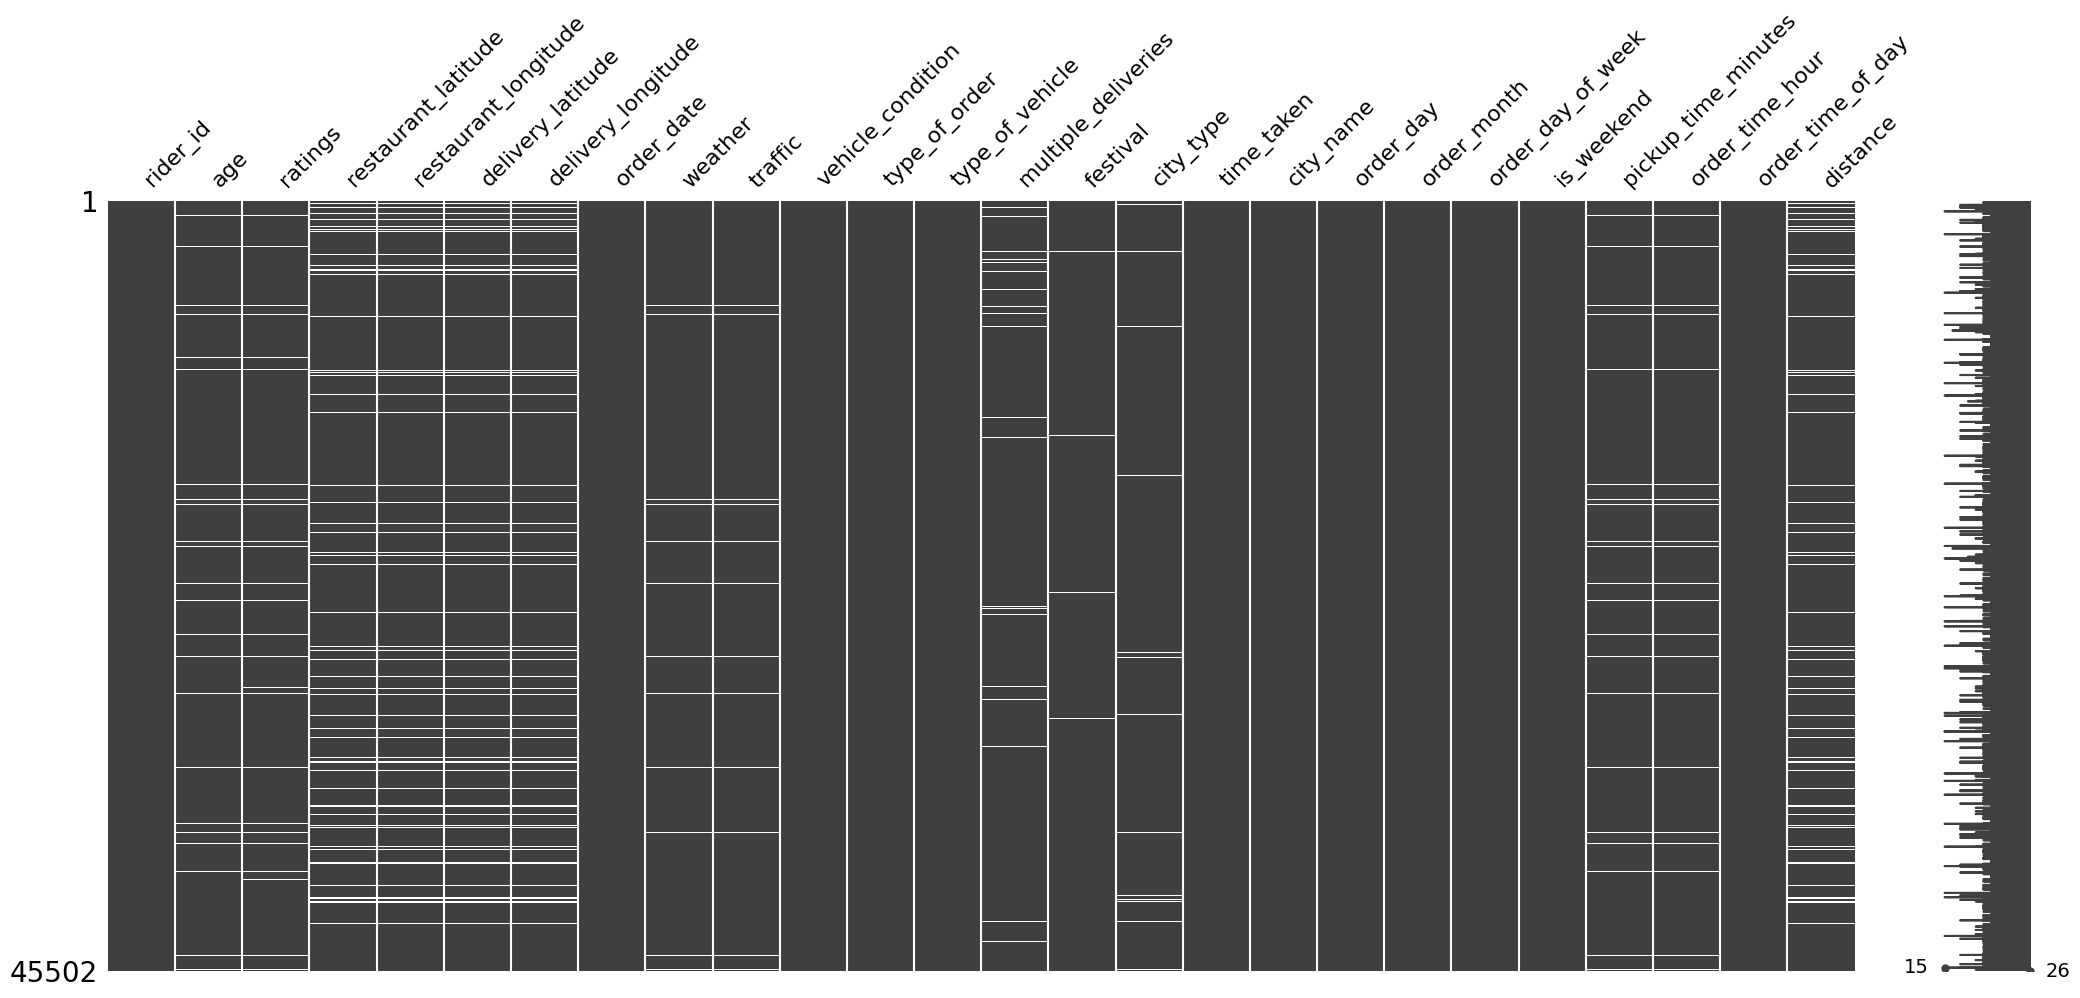

In [14]:
msno.matrix(df_final)

<Axes: >

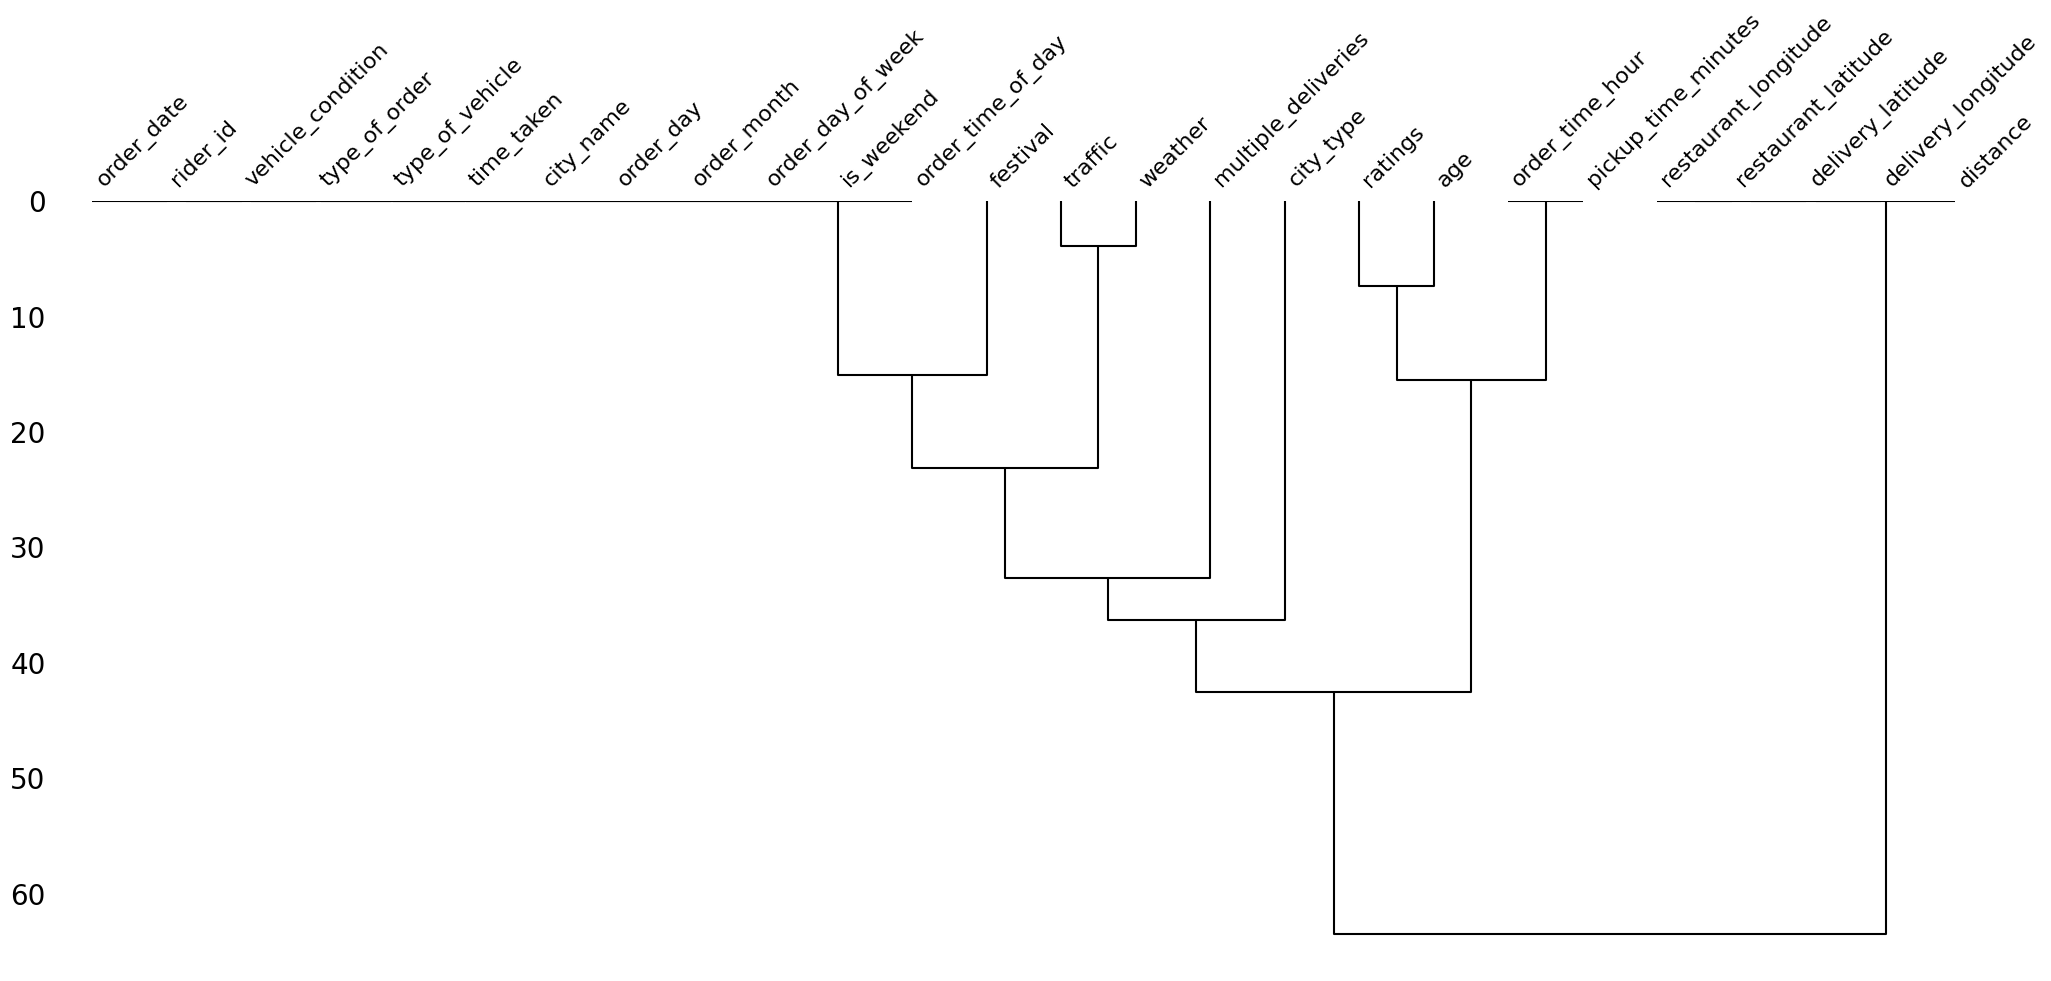

In [15]:
msno.dendrogram(df_final)

In [17]:
def numerical_analysis(dataframe, column_name, cat_col=None, bins="auto"):
    # create the figure
    fig = plt.figure(figsize=(15, 10))
    # generate the layout
    grid = GridSpec(nrows=2, ncols=2, figure=fig)
    # set subplots
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])
    # plot the kdeplot
    sns.kdeplot(data=dataframe, x=column_name, hue=cat_col, ax=ax1)
    # plot the boxplot
    sns.boxplot(data=dataframe, x=column_name, hue=cat_col, ax=ax2)
    # plot the histogram
    sns.histplot(data=dataframe, x=column_name, bins=bins, hue=cat_col, kde=True, ax=ax3)
    plt.tight_layout()
    plt.show()
def numerical_categorical_analysis(dataframe, cat_column_1, num_column):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[1])
    plt.tight_layout()
    plt.show()


def categorical_analysis(dataframe, column_name):
    # print the values counts of categories
    display(
        pd.DataFrame({
            "Count": (
                dataframe[column_name]
                .value_counts()),
            "Percentage": (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .astype("str")
                .add("%")
                )
        })
    )
    print("*" * 50)
    # get unique categories
    unique_categories = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f"The unique categories in {column_name} column are {unique_categories}")
    print("*" * 50)
    print(f"The number of categories in {column_name} column are {number_of_categories}")
    # plot countplot
    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()


def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, gap=0.1, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, gap=0.1,
                   y=num_column,hue=cat_column_2, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1,
                  y=num_column,hue=cat_column_2,dodge=True,ax=ax2[1])
    plt.tight_layout()
    plt.show()

def chi_2_test(dataframe, col1, col2, alpha= 0.05):
    data = (
        dataframe.loc[:, [col1, col2]]
        .dropna()
    )
    # create contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])
    # perform chi-squared test
    _, p_val, _, _ = chi2_contingency(contingency_table)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant association between {col1} and {col2}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant association between {col1} and {col2}.")

def anova_test(dataframe, num_col, cat_col, alpha=0.05):
    data = (
        dataframe.loc[:, [num_col, cat_col]]
        .dropna()
    )
    cat_group = data.groupby(cat_col)
    groups = [group[num_col].values for _, group in cat_group]
    f_stat, p_val = f_oneway(*groups)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant relationship between {num_col} and {cat_col}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant relationship between {num_col} and {cat_col}.")

def test_for_normality(dataframe, column_name, alpha=0.05):
    data = dataframe[column_name]
    print("Jarque Bera Test for Normality")
    _, p_val = jarque_bera(data)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. The data is not normally distributed.")
    else:
        print(f"Fail to reject the null hypothesis. The data is normally distributed.",end="\n\n")

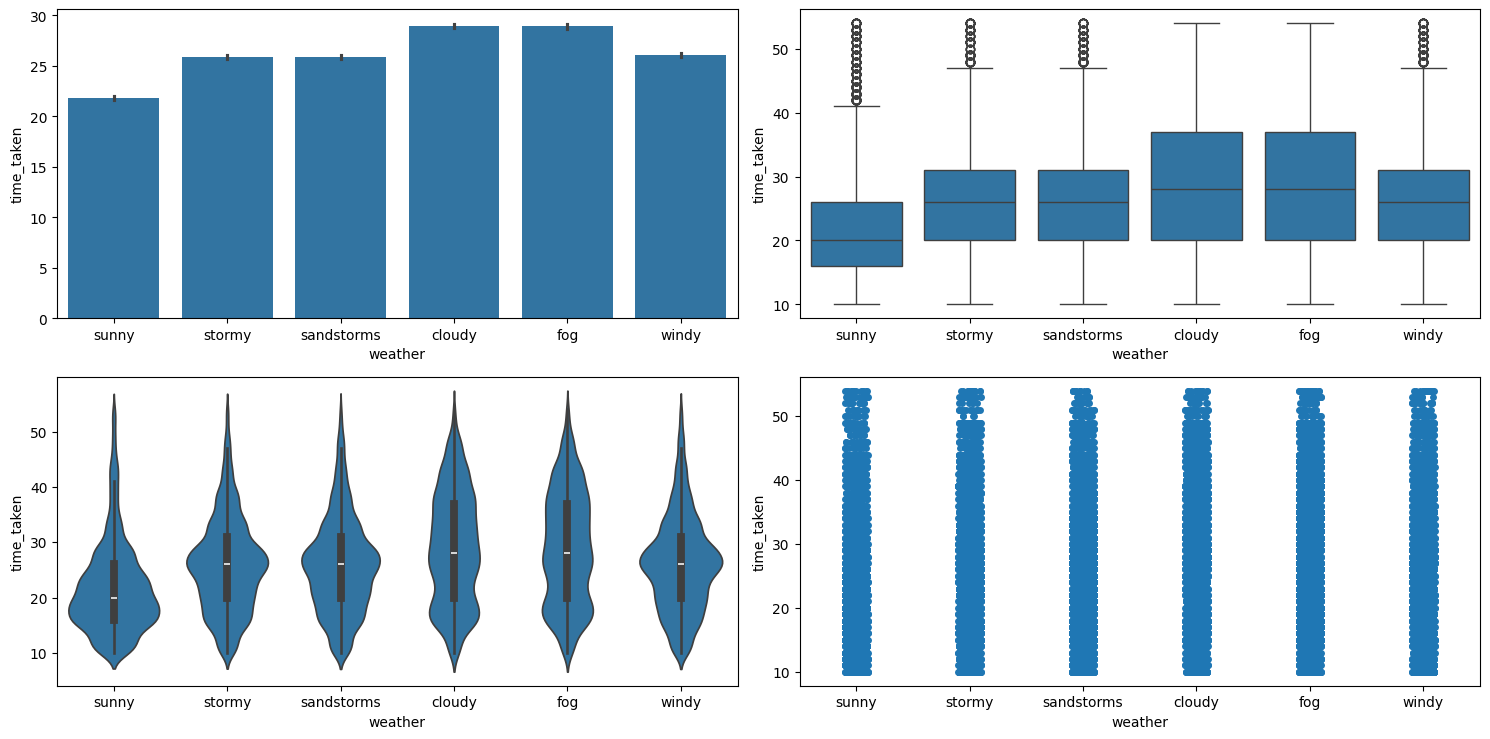

In [ ]:
numerical_categorical_analysis(df_final, cat_column_1="weather", num_column="time_taken")

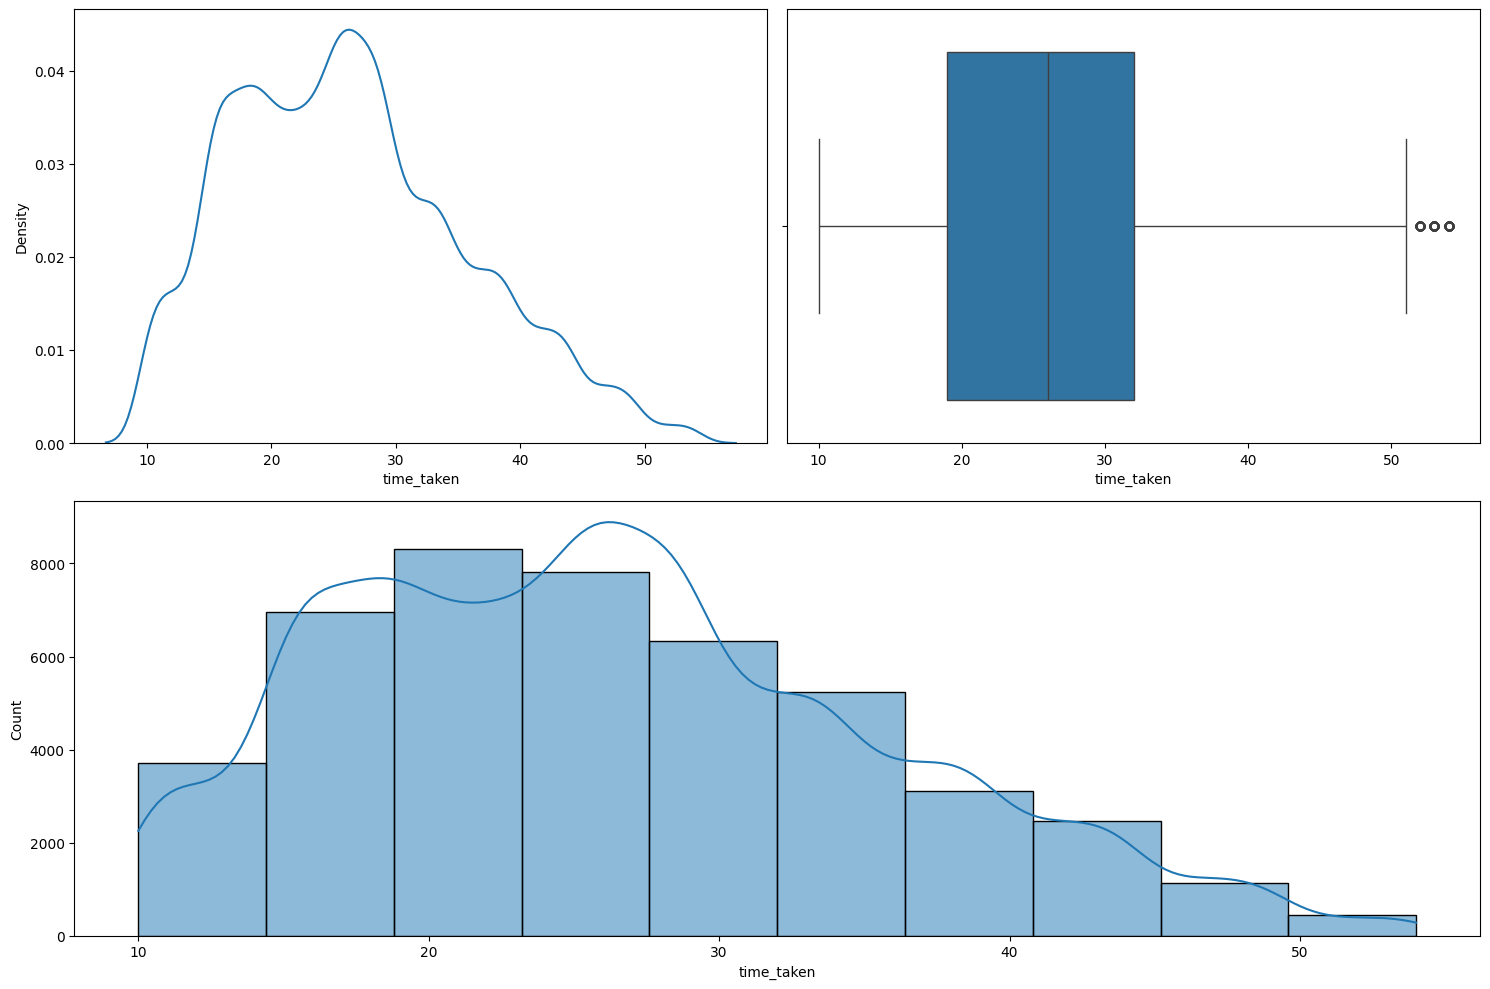

In [21]:
# numerical analysis

numerical_analysis(df_final, 'time_taken',bins=10)

Observations:

The target column is not fully continuous in nature.

The target column shows dual modality with two peaks- One peak around the 17-18 mark and other around 26-27 mark.

The target column has some extreme points which can be thought of as outliers but they are just extreme and rare, not outliers. 50 min time is possible for delivery in certain rare cases.

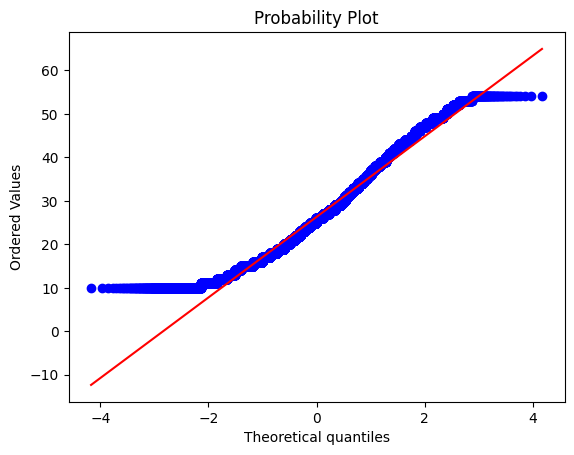

In [20]:
# plot QQ plot for the target

probplot(df_final['time_taken'], plot=plt)
plt.show()

In [22]:
# tests for normailty

test_for_normality(df_final, 'time_taken')

Jarque Bera Test for Normality
0.0
Reject the null hypothesis. The data is not normally distributed.


In [23]:
# check out the rows where data is acting as outlier

target_25_per, target_75_per = np.percentile(df_final['time_taken'], [25, 75])
iqr = target_75_per - target_25_per

upper_bound = target_75_per + (1.5 * iqr)

df_final.loc[(df_final['time_taken'] > upper_bound),"traffic"].value_counts()

traffic
jam     241
high     24
Name: count, dtype: int64

In [24]:
df_final.loc[(df_final['time_taken'] > upper_bound),"weather"].value_counts()

weather
fog           57
sunny         51
cloudy        44
windy         44
stormy        37
sandstorms    32
Name: count, dtype: int64

In [25]:
# average distances
avg_distance = df_final.loc[:,"distance"].mean()
avg_distance_extreme = df_final.loc[(df_final['time_taken'] > upper_bound),"distance"].mean()

print(avg_distance, avg_distance_extreme)

9.71929632319958 13.29215081388658


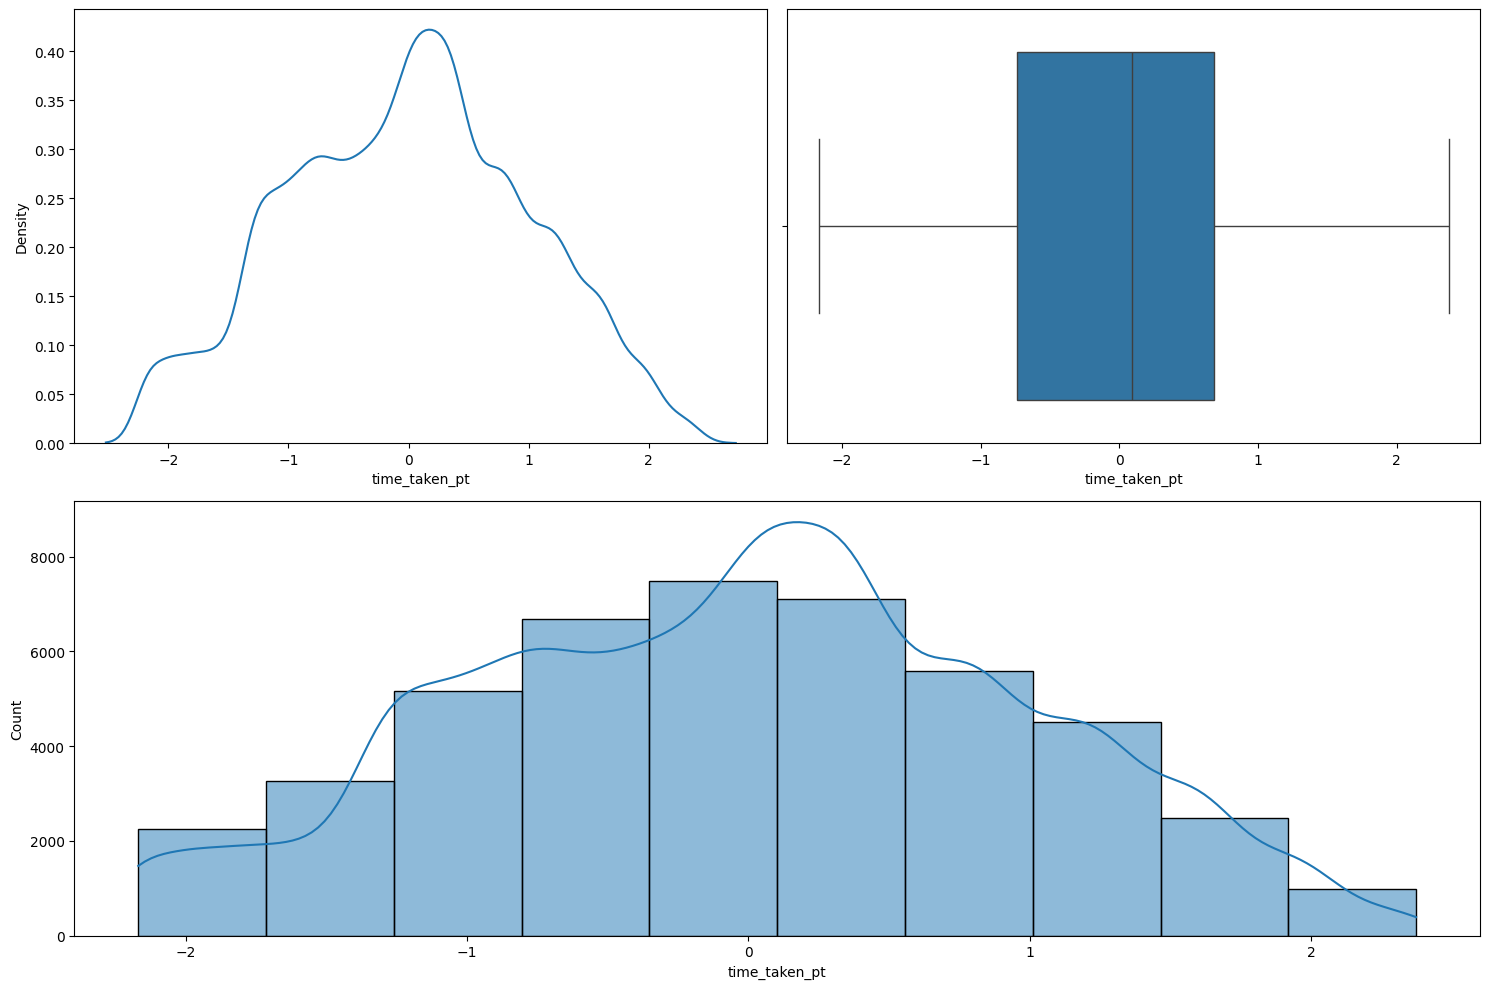

In [26]:
# fix traget column using transformation

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df_final['time_taken_pt'] = pt.fit_transform(df_final[['time_taken']])

numerical_analysis(df_final, "time_taken_pt", bins=10)

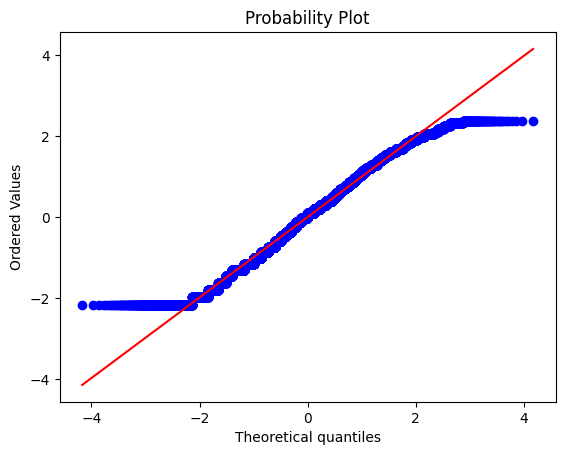

In [27]:
# plot QQ plot for the target after transformation

probplot(df_final['time_taken_pt'], plot=plt)
plt.show()

## Rider_ID


In [28]:
# datatype of rider id

df_final['rider_id'].dtype

<StringDtype(na_value=nan)>

In [29]:
df_final[["rider_id","age","ratings"]]

,rider_id,age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
45497,JAPRES04DEL01,30.0,4.8
45498,AGRRES16DEL01,21.0,4.6
45499,CHENRES08DEL03,30.0,4.9
45500,COIMBRES11DEL01,20.0,4.7


In [30]:
# sample of data

rider_id_group = df_final[["rider_id","age","ratings"]].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,age,ratings
92,AGRRES010DEL01,34.0,4.7
4554,AGRRES010DEL01,38.0,4.7
7738,AGRRES010DEL01,21.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
5094,VADRES20DEL03,35.0,4.9
5146,VADRES20DEL03,37.0,4.9
9753,VADRES20DEL03,38.0,4.8


In [31]:
# check for duplicates

df_final[["rider_id","age","ratings"]].dropna().duplicated(keep=False).sum()

np.int64(10155)

In [32]:
# filter the duplicates

(
    df_final
    .loc[(df_final[["rider_id","age","ratings"]].duplicated(keep=False)),["rider_id","age","ratings"]]
    .dropna()
    .sort_values(["rider_id"])
)

,rider_id,age,ratings
18533,AGRRES03DEL02,24.0,4.9
40285,AGRRES03DEL02,24.0,4.9
26275,AGRRES03DEL03,30.0,4.7
28473,AGRRES03DEL03,30.0,4.7
28150,AGRRES06DEL02,36.0,4.9
...,...,...,...
44746,VADRES20DEL02,29.0,4.8
5094,VADRES20DEL03,35.0,4.9
5146,VADRES20DEL03,37.0,4.9
17963,VADRES20DEL03,35.0,4.9


Above is not useful for analysis

# AGe

In [33]:
# statistical summary

df_final['age'].describe()

count    43648.000000
mean        29.555008
std          5.761482
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

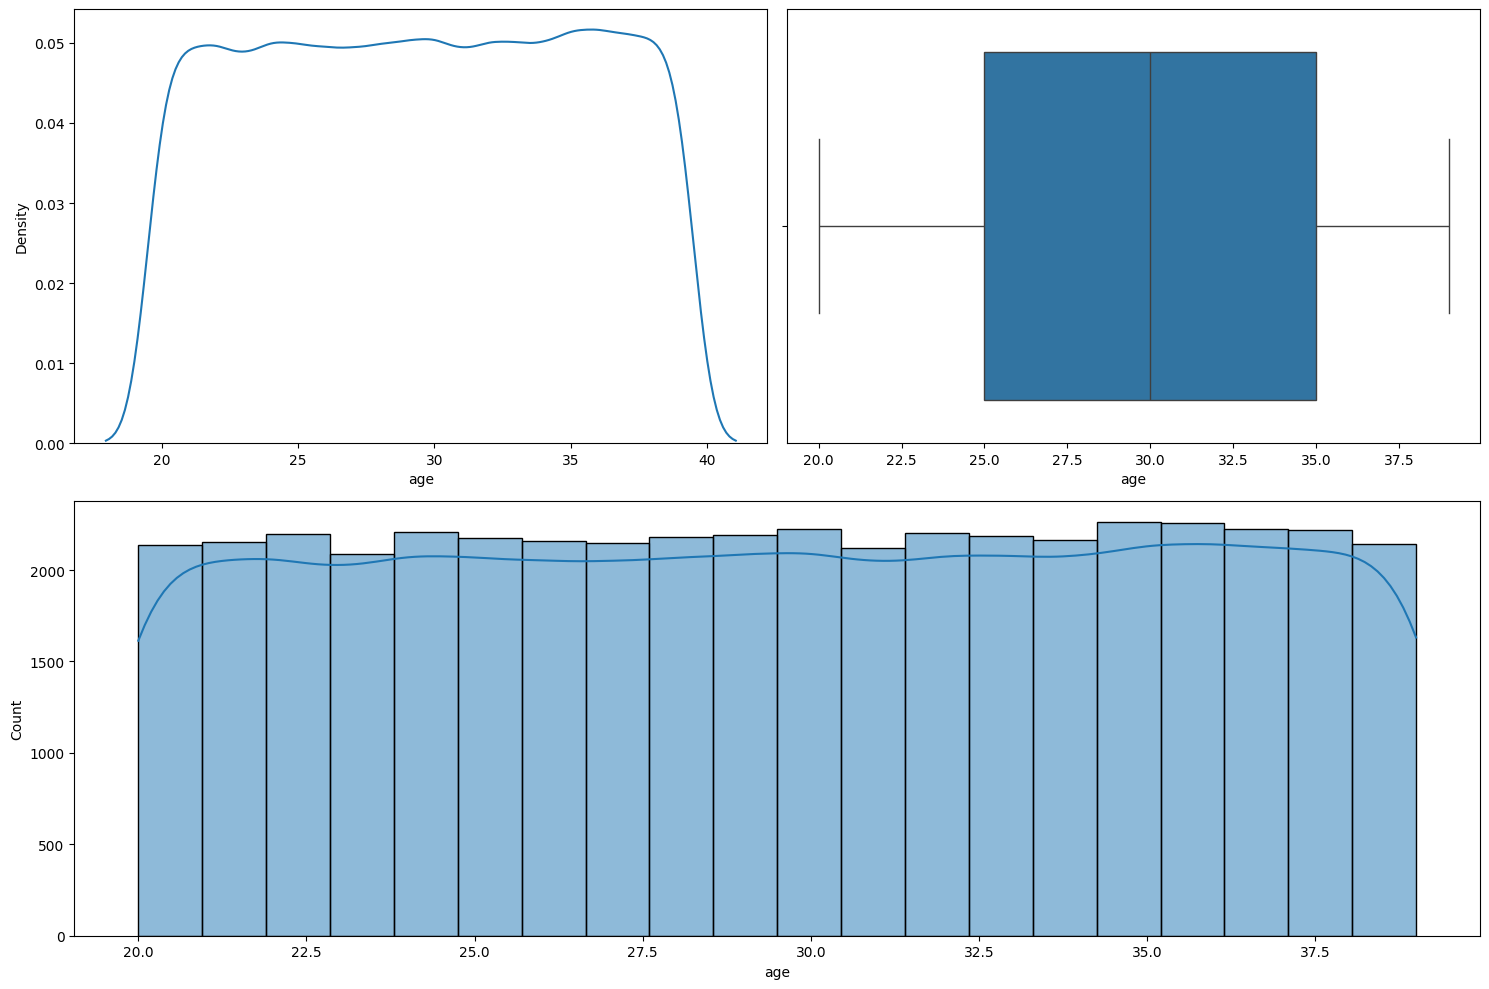

In [34]:
# numerical analysis for age

numerical_analysis(df_final, 'age',bins=20)

<Axes: xlabel='age', ylabel='time_taken'>

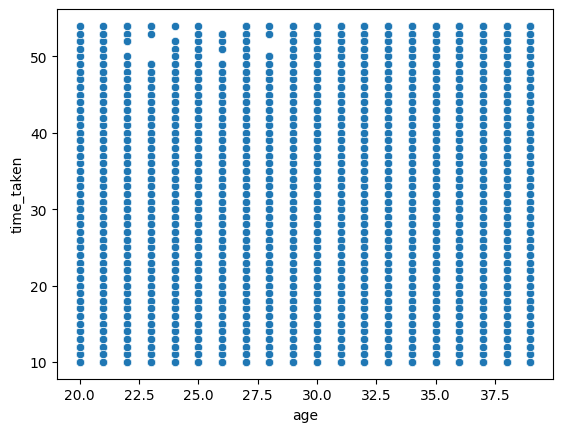

In [35]:
#relationship bw target and age
sns.scatterplot(data=df_final, x='age', y='time_taken')

# Age of the rider does not show any impact on timetaken to deliver

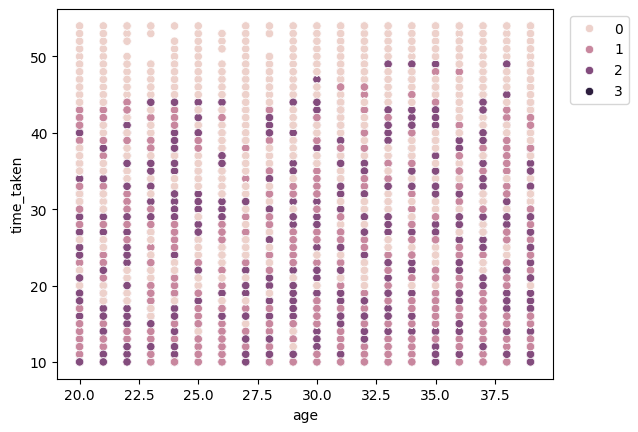

In [36]:
sns.scatterplot(data=df_final, x='age', y='time_taken', hue="vehicle_condition")
plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
plt.show()

# above chart means those who have good vehicle condition are generally suggested for longer deliveries

<Axes: xlabel='type_of_vehicle', ylabel='age'>

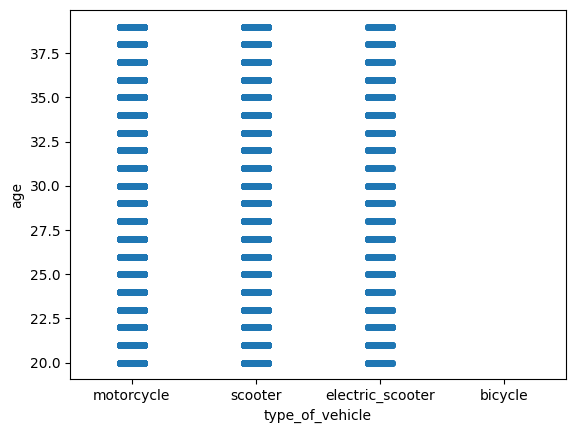

In [37]:
# preferences of vehicle type based on age

sns.stripplot(df_final,x='type_of_vehicle',y='age')

# ratings

In [38]:
df_final['ratings'].describe()

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

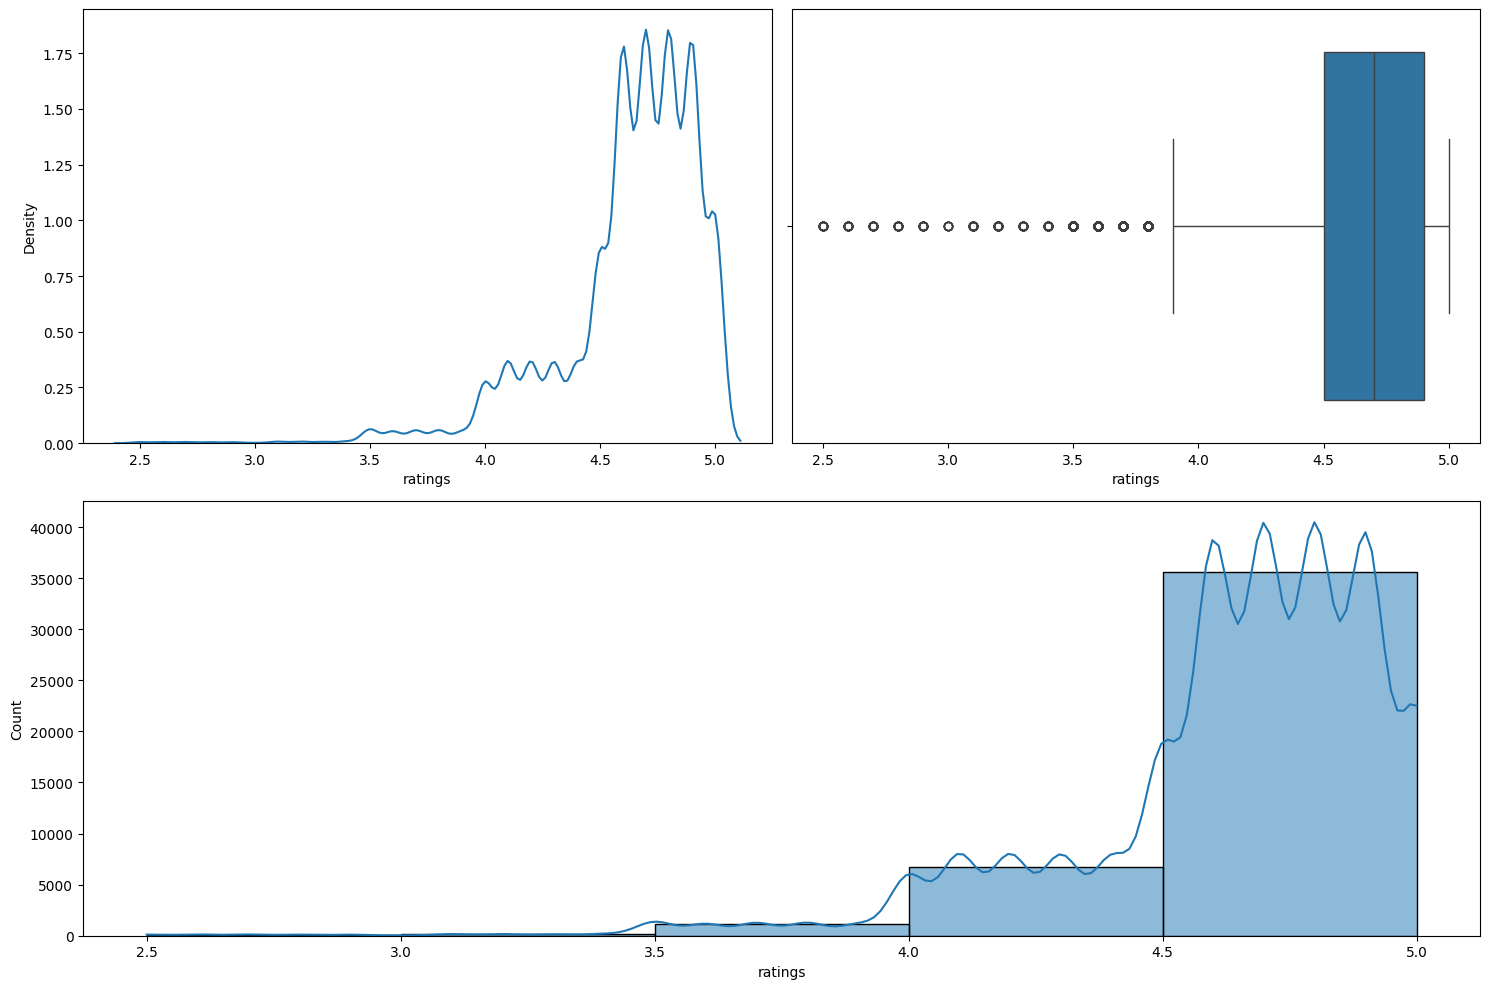

In [39]:
# numerical analysis

numerical_analysis(df_final, 'ratings',bins=5)

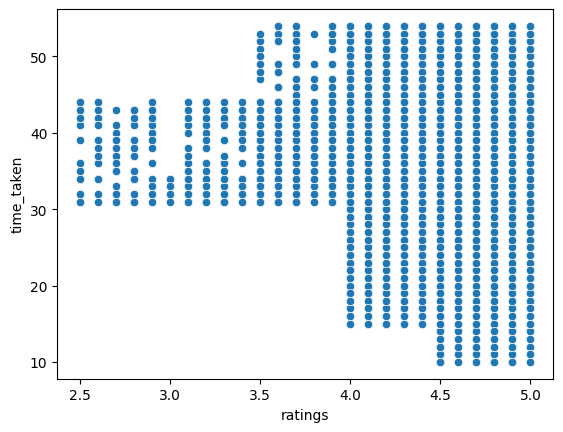

In [40]:
# does ratings affect delivery time

sns.scatterplot(data=df_final, x='ratings', y='time_taken')
plt.show()

It seems like riders with more ratings get more orders

Higher ratings equates to more work and more income opportunities

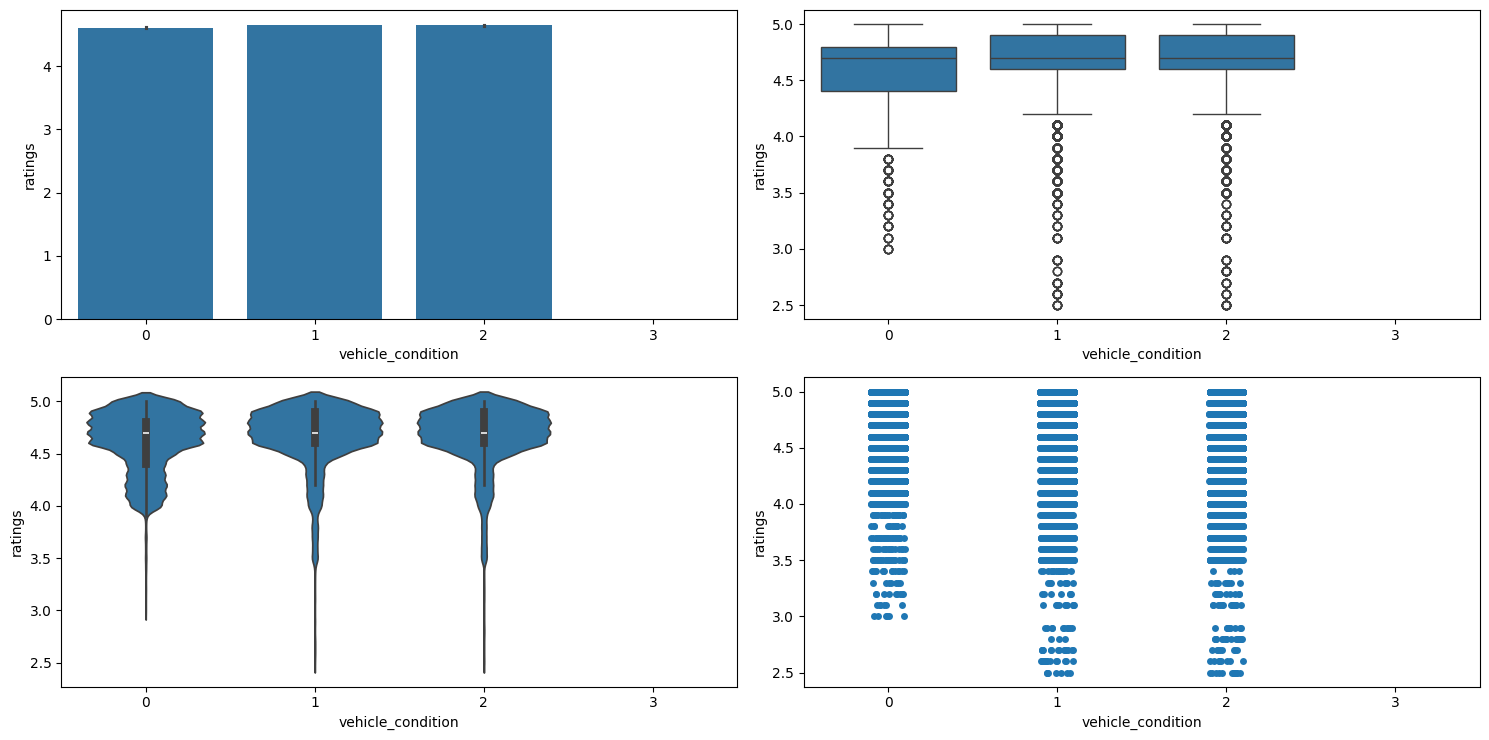

In [41]:
# does ratings get affected by vehicle type

numerical_categorical_analysis(df_final, 'vehicle_condition', 'ratings')

Yes they do

1. The more worst the vehicle condition is, the more lower the rating gets.
2. The category 3 has no data means there are NaN values. This simply means that customers avoid rating their riders even rating of 1 when the vehicle condition is bad.

In [42]:
(
    df_final[["ratings","vehicle_condition"]]
    .loc[df_final["vehicle_condition"]==3,"ratings"]
    .value_counts(dropna=False)
)

ratings
NaN    429
Name: count, dtype: int64

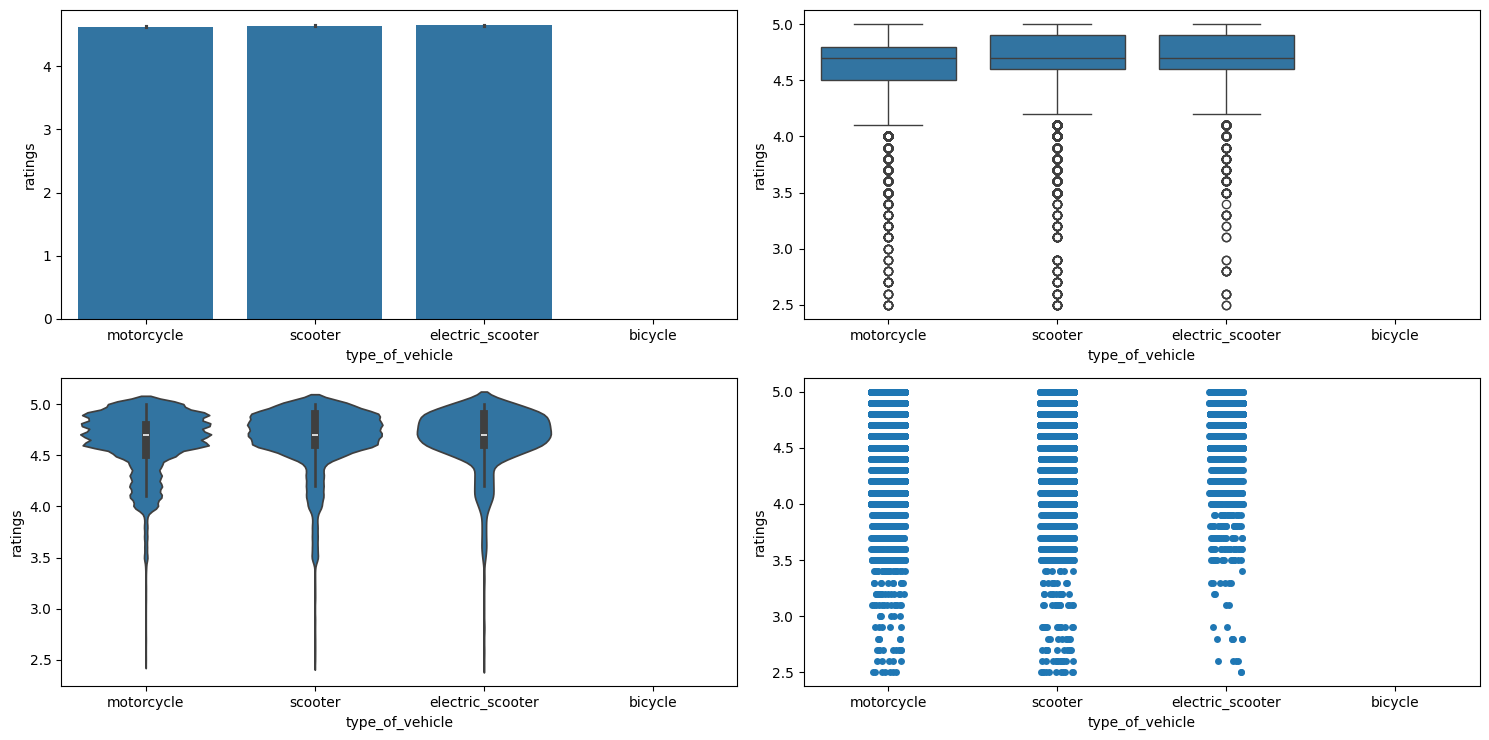

In [43]:
# does type of vehicle affects ratings

numerical_categorical_analysis(df_final, 'type_of_vehicle', 'ratings')

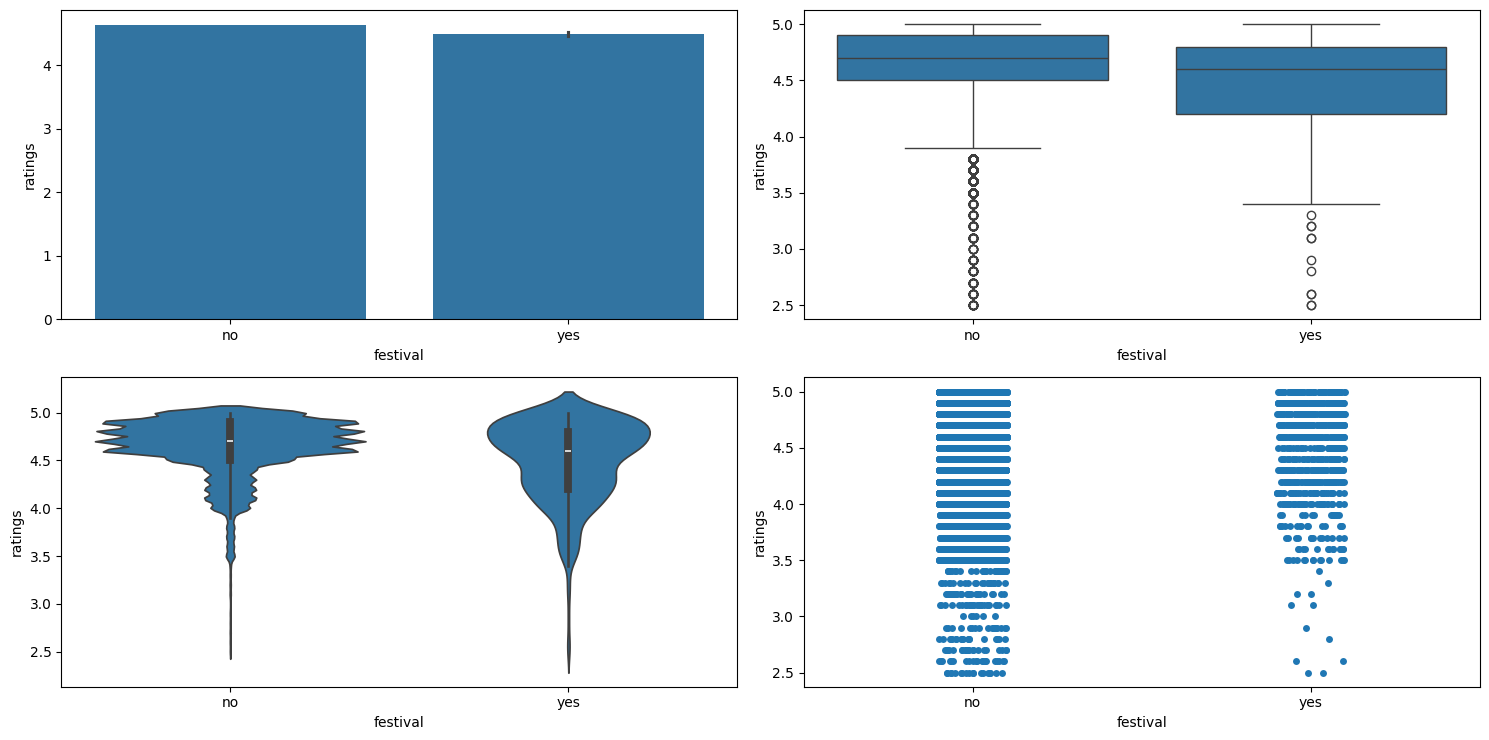

In [44]:
# festvals and rider ratings

numerical_categorical_analysis(df_final, 'festival', 'ratings')

# Location Based Features

In [45]:
df_final.columns[3:7].tolist() + ["city_name"]

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city_name']

In [46]:
# location subset

location_subset = df_final.loc[:,df_final.columns[3:7].tolist() + ["city_name"]]

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45497,26.902328,75.794257,26.912328,75.804257,JAP
45498,NaN,NaN,NaN,NaN,AGR
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [47]:
# drop missing values

location_subset.dropna(inplace=True)

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45496,23.371292,85.327872,23.481292,85.437872,RANCHI
45497,26.902328,75.794257,26.912328,75.804257,JAP
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [48]:
# plot deliveries on map

delivery_df = pd.DataFrame({
    'latitude': location_subset['delivery_latitude'],
    'longitude': location_subset['delivery_longitude'],
    "city_name": location_subset["city_name"]
})


# Create a map using Plotly's scatter_mapbox
fig = px.scatter_mapbox(
    delivery_df,
    lat='latitude',
    lon='longitude',
    title="Delivery Points",
    hover_name="city_name"
)

# Update the layout for the map of India
fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_center={"lat": 20.5937, "lon": 78.9629},  # Centered over India
    mapbox_zoom=3,
)

# Show the plot
fig.show()

C:\Users\ARYAN PRAJAPATI\AppData\Local\Temp\ipykernel_6540\2667924057.py:11: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


# Order date

In [49]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'time_taken_pt'],
      dtype='str')

In [50]:
df_final.filter(like="order")

,order_date,type_of_order,order_day,order_month,order_day_of_week,order_time_hour,order_time_of_day
0,19-03-2022,snack,19,3,saturday,11.0,morning
1,25-03-2022,snack,25,3,friday,19.0,evening
2,19-03-2022,drinks,19,3,saturday,8.0,morning
3,05-04-2022,buffet,5,4,tuesday,18.0,evening
4,26-03-2022,snack,26,3,saturday,13.0,afternoon
...,...,...,...,...,...,...,...
45497,24-03-2022,meal,24,3,thursday,11.0,morning
45498,16-02-2022,buffet,16,2,wednesday,19.0,evening
45499,11-03-2022,drinks,11,3,friday,23.0,night
45500,07-03-2022,snack,7,3,monday,13.0,afternoon


In [51]:
# order date columns

order_date_subset = df_final.loc[:,["order_date","order_day","order_month","order_day_of_week","is_weekend","festival"]]

order_date_subset

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,19-03-2022,19,3,saturday,1,no
1,25-03-2022,25,3,friday,0,no
2,19-03-2022,19,3,saturday,1,no
3,05-04-2022,5,4,tuesday,0,no
4,26-03-2022,26,3,saturday,1,no
...,...,...,...,...,...,...
45497,24-03-2022,24,3,thursday,0,no
45498,16-02-2022,16,2,wednesday,0,no
45499,11-03-2022,11,3,friday,0,no
45500,07-03-2022,7,3,monday,0,no


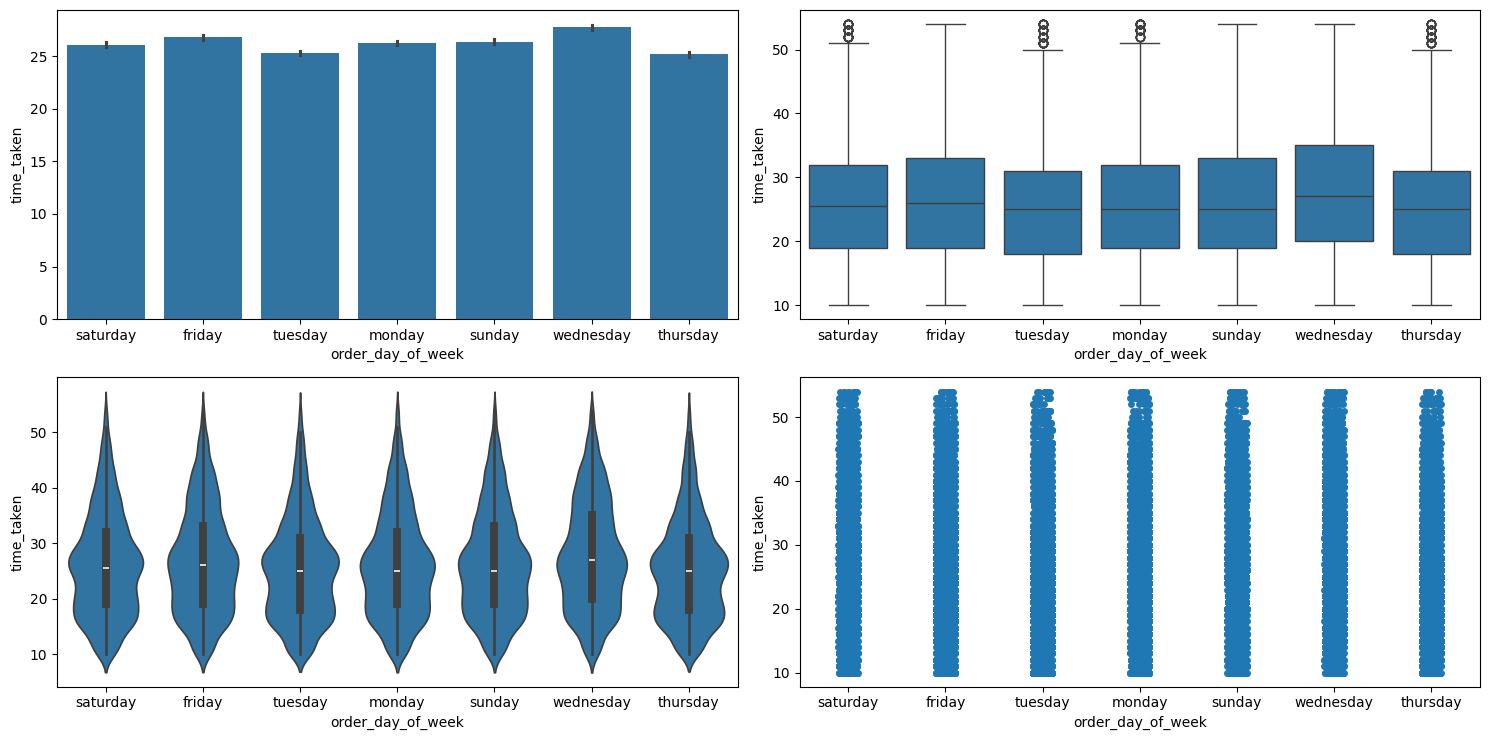

In [52]:
# analysis between day of week and target

numerical_categorical_analysis(df_final, "order_day_of_week", "time_taken")

In [53]:
# do weekends have an impact on traffic

chi_2_test(df_final, "is_weekend", "traffic")

0.6845961396354259
Fail to reject the null hypothesis. There is no significant association between is_weekend and traffic.


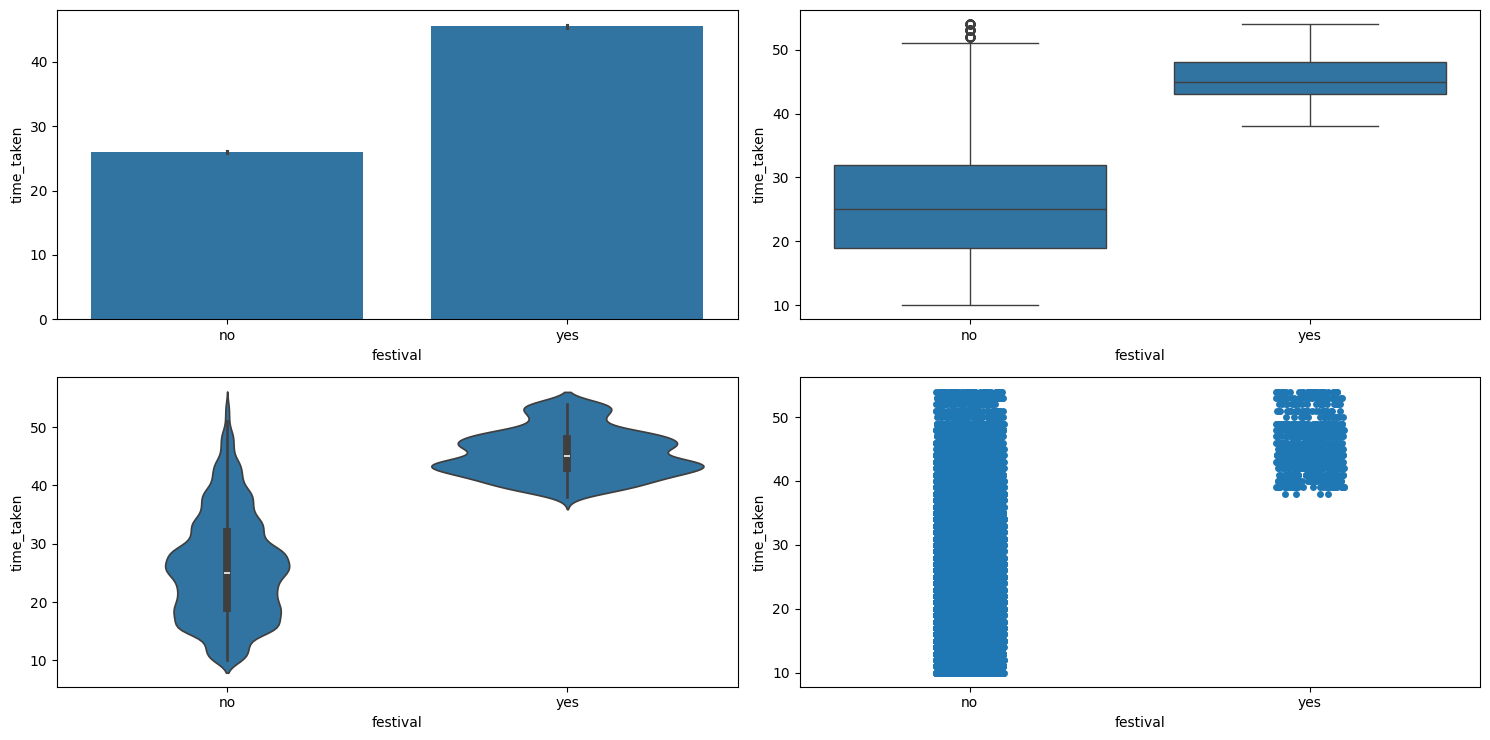

In [54]:
# festivals and target analysis

numerical_categorical_analysis(df_final, "festival", "time_taken")

Observations:

The avg time it takes for delivery varies when there is a festival.

The range of delivery time is shorter when there is a festival with lesser variation, which means on a festival delivery times usually takes longer.


In [55]:
# do festival affect traffic

chi_2_test(df_final, "festival", "traffic")

1.1223471129146869e-153
Reject the null hypothesis. There is a significant association between festival and traffic.


In [56]:
df_final.pivot_table(index="traffic",columns="festival",values="time_taken",aggfunc="mean")

festival,no,yes
traffic,,
high,27.010373,45.826087
jam,30.538039,46.093651
low,21.284332,42.020000
medium,26.550288,43.715385


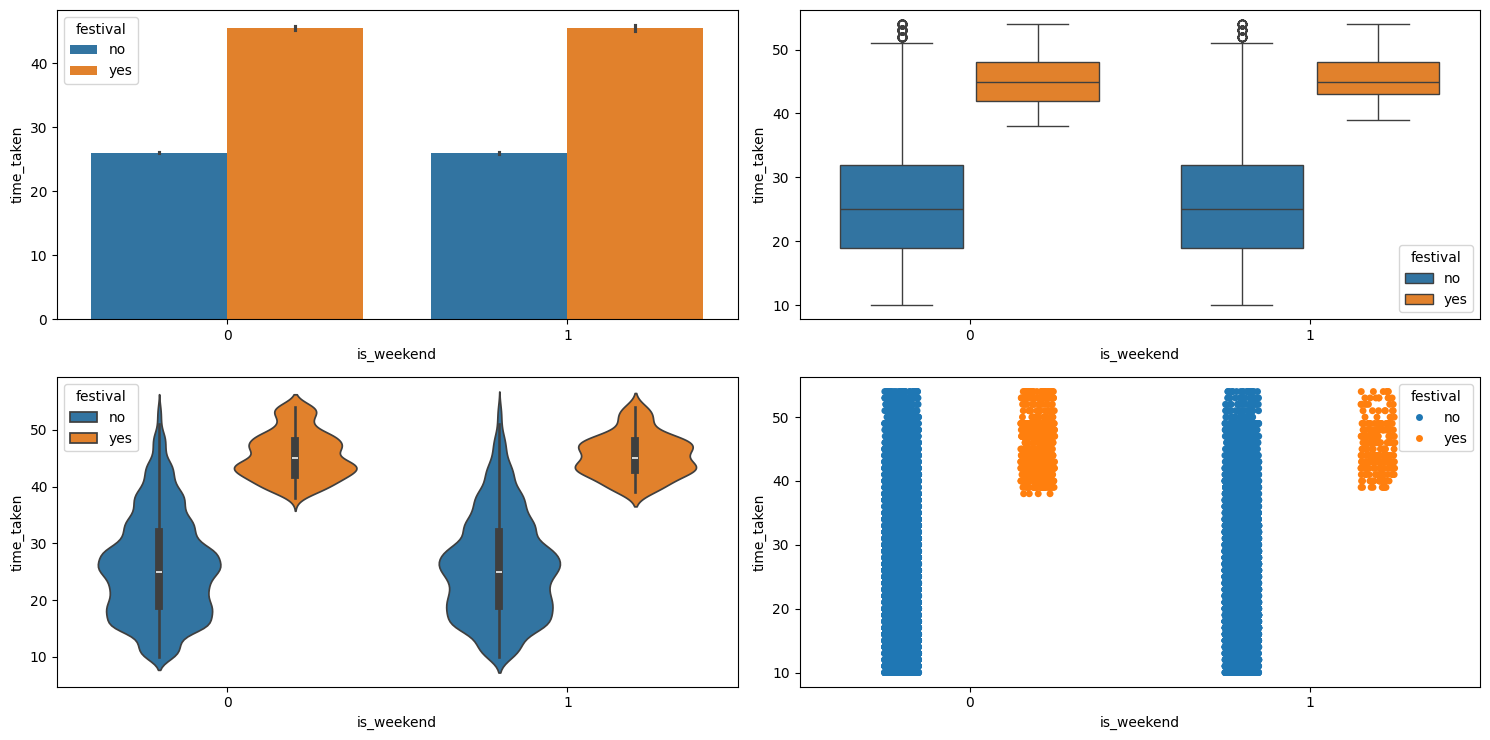

In [57]:
# does a weekend and a festival combined have an effect on delivery times

multivariate_analysis(df_final, "time_taken", "is_weekend", "festival")

## Order Time

In [58]:
# time related columns

time_subset = df_final.loc[:,["order_time_hour","order_time_of_day","pickup_time_minutes"]]

time_subset

,order_time_hour,order_time_of_day,pickup_time_minutes
0,11.0,morning,15.0
1,19.0,evening,5.0
2,8.0,morning,15.0
3,18.0,evening,10.0
4,13.0,afternoon,15.0
...,...,...,...
45497,11.0,morning,10.0
45498,19.0,evening,15.0
45499,23.0,night,15.0
45500,13.0,afternoon,5.0


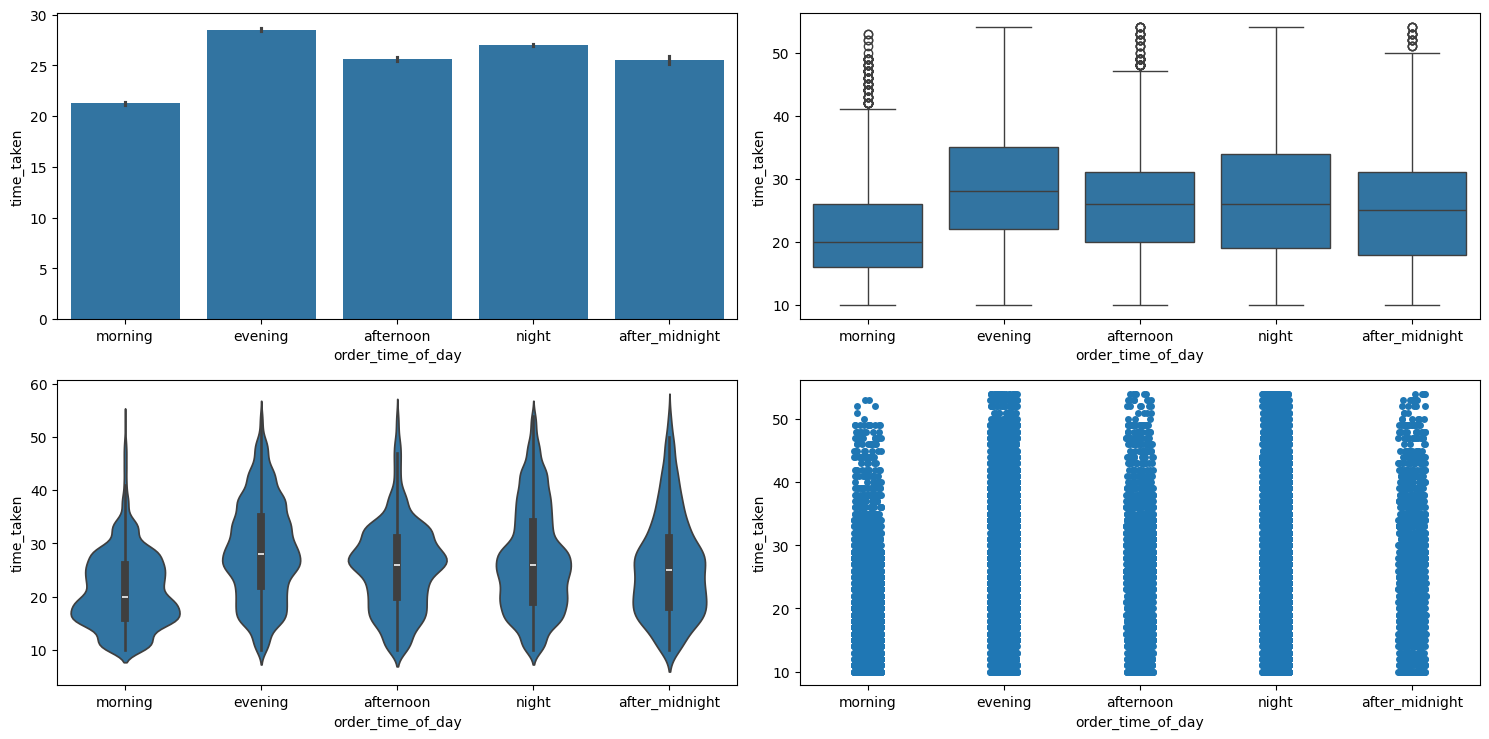

In [59]:
# does time of day affects delivery times

numerical_categorical_analysis(df_final, "order_time_of_day", "time_taken")

In [60]:
# anova test

anova_test(df_final, "time_taken", "order_time_of_day")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and order_time_of_day.


In [61]:
# Top 5 times(hrs) of the day in which customers  order the most

df_final["order_time_hour"].value_counts().head(5)

order_time_hour
21.0    4686
19.0    4595
22.0    4576
20.0    4539
23.0    4511
Name: count, dtype: int64

,Count,Percentage
order_time_hour,,
21.0,4686,10.68%
19.0,4595,10.48%
22.0,4576,10.43%
20.0,4539,10.35%
23.0,4511,10.28%
18.0,4480,10.21%
17.0,4278,9.75%
10.0,1991,4.54%
11.0,1962,4.47%


**************************************************
The unique categories in order_time_hour column are [11.0, 19.0, 8.0, 18.0, 13.0, 21.0, 17.0, 20.0, 14.0, 9.0, 22.0, 12.0, 23.0, nan, 10.0, 16.0, 15.0, 0.0]
**************************************************
The number of categories in order_time_hour column are 17


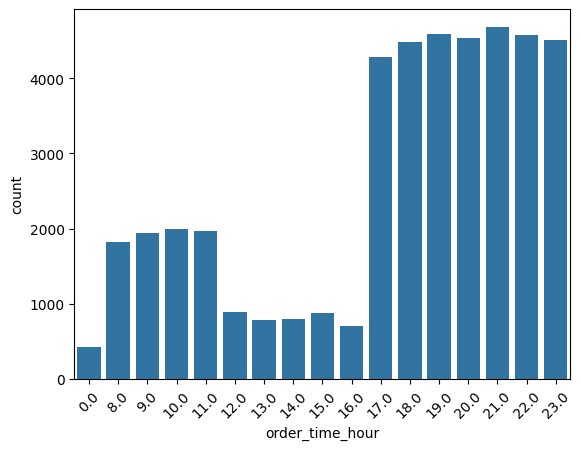

In [62]:
# categorical analysis on order_time_hour

categorical_analysis(df_final, "order_time_hour")

,Count,Percentage
order_time_of_day,,
night,18312,40.24%
evening,13353,29.35%
morning,7718,16.96%
afternoon,4049,8.9%
after_midnight,2070,4.55%


**************************************************
The unique categories in order_time_of_day column are ['morning', 'evening', 'afternoon', 'night', 'after_midnight']
**************************************************
The number of categories in order_time_of_day column are 5


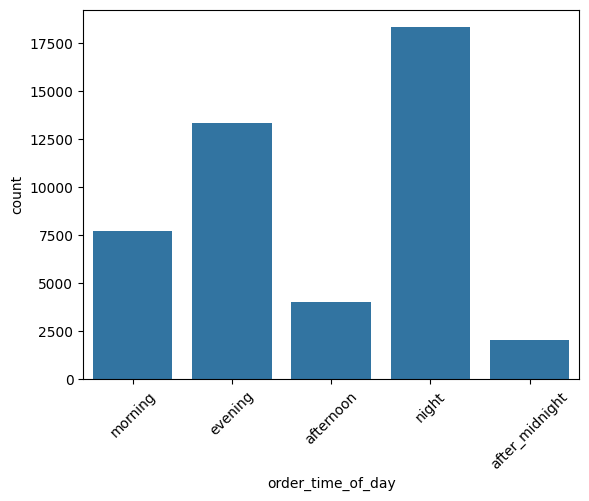

In [63]:
# categorical analysis on time of day

categorical_analysis(df_final, "order_time_of_day")

# Traffic

In [64]:
# datatype of traffic column

df_final['traffic'].dtype

<StringDtype(na_value=nan)>

,Count,Percentage
traffic,,
low,15477,34.4%
jam,14143,31.43%
medium,10947,24.33%
high,4425,9.84%


**************************************************
The unique categories in traffic column are ['high', 'jam', 'low', 'medium', nan]
**************************************************
The number of categories in traffic column are 4


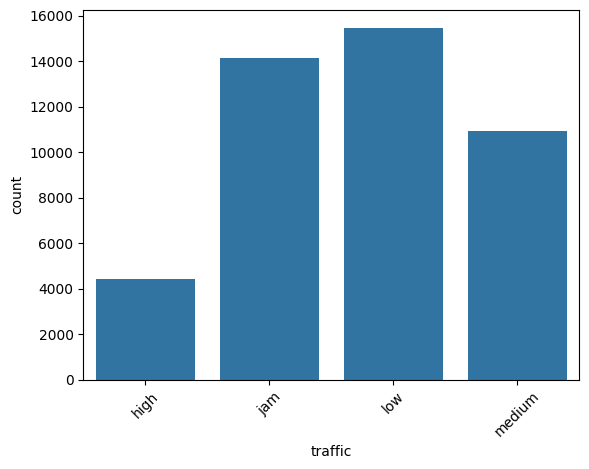

In [65]:
# categorical analysis on traffic

categorical_analysis(df_final, "traffic")

In [66]:
# does traffic depends on type of city

chi_2_test(df_final, "traffic", "city_type")

2.3390790568495405e-104
Reject the null hypothesis. There is a significant association between traffic and city_type.


In [67]:
# does traffic depends on city

chi_2_test(df_final, "traffic", "city_name")

0.4978080180955253
Fail to reject the null hypothesis. There is no significant association between traffic and city_name.


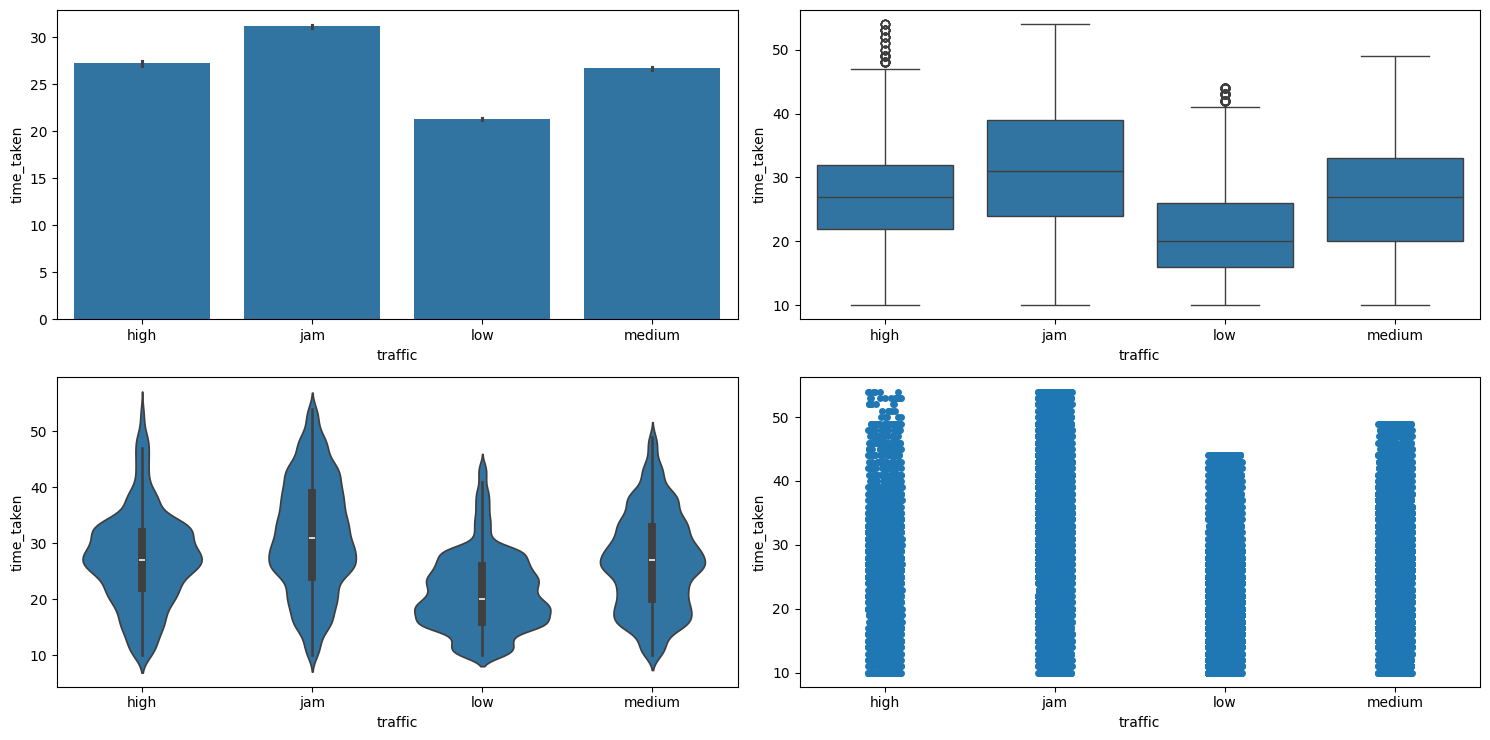

In [68]:
# does traffic affects delivery times

numerical_categorical_analysis(df_final, "traffic", "time_taken")

In [69]:
# hypothesis test on does traffic affects delivery times

anova_test(df_final, "time_taken", "traffic")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and traffic.


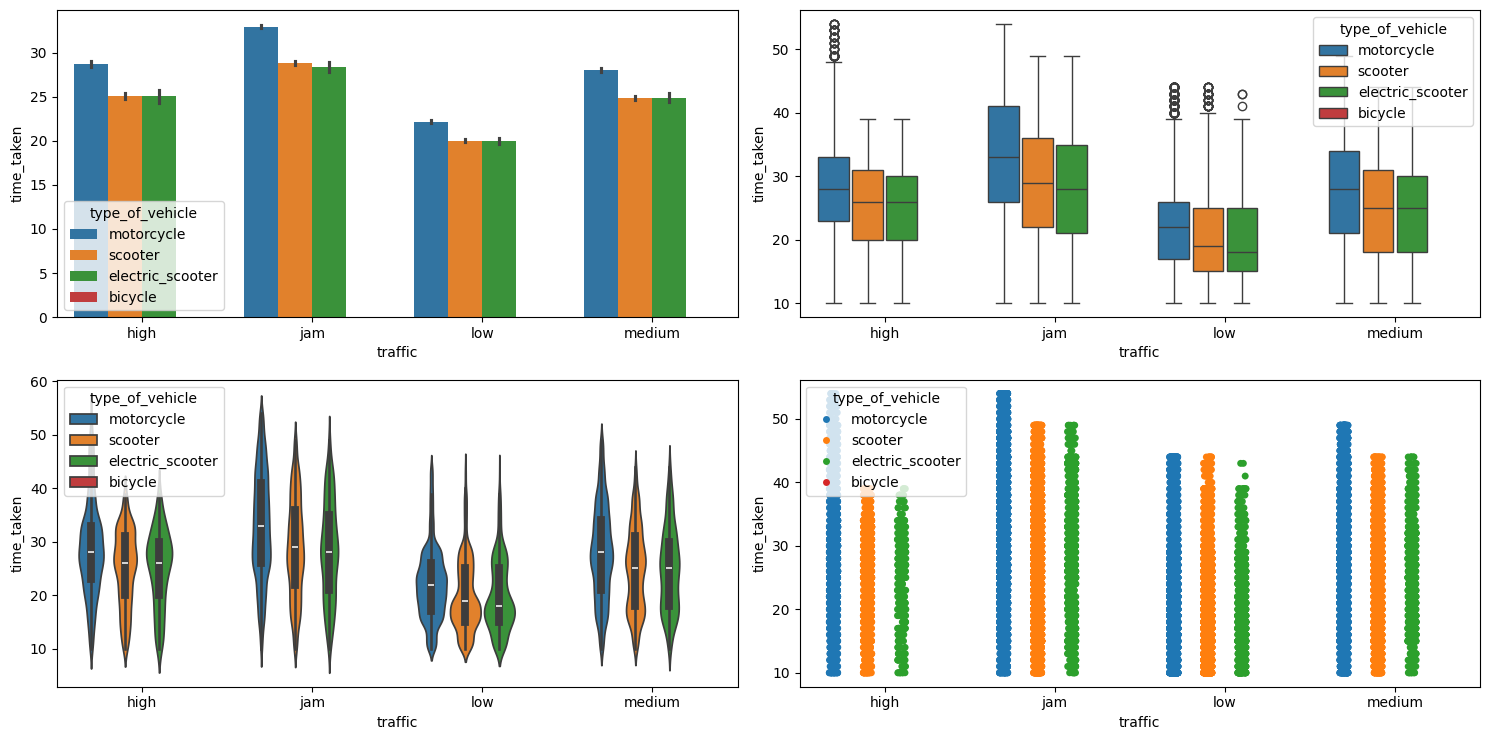

In [70]:
# are some vehicle types more suitable in traffic than others

multivariate_analysis(df_final, "time_taken", "traffic", "type_of_vehicle")


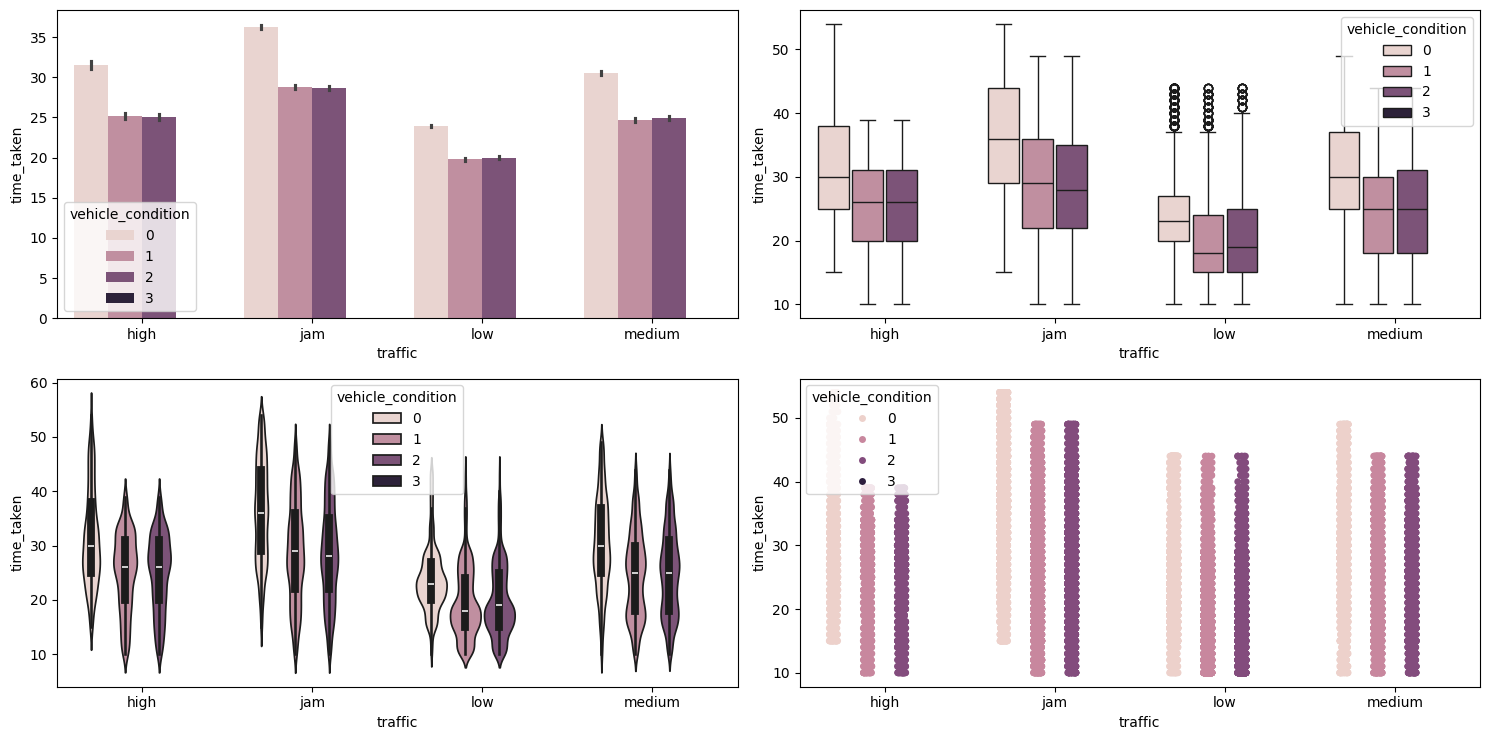

In [71]:
# does vehicle condition in traffic situations affects delivery times

multivariate_analysis(df_final, "time_taken", "traffic", "vehicle_condition")

Dont make wrong interpretations that good condition vehicles takes longer times on avg

This simply means that good vehicles are preferred for deliveries during festivals which results in longer delivery times

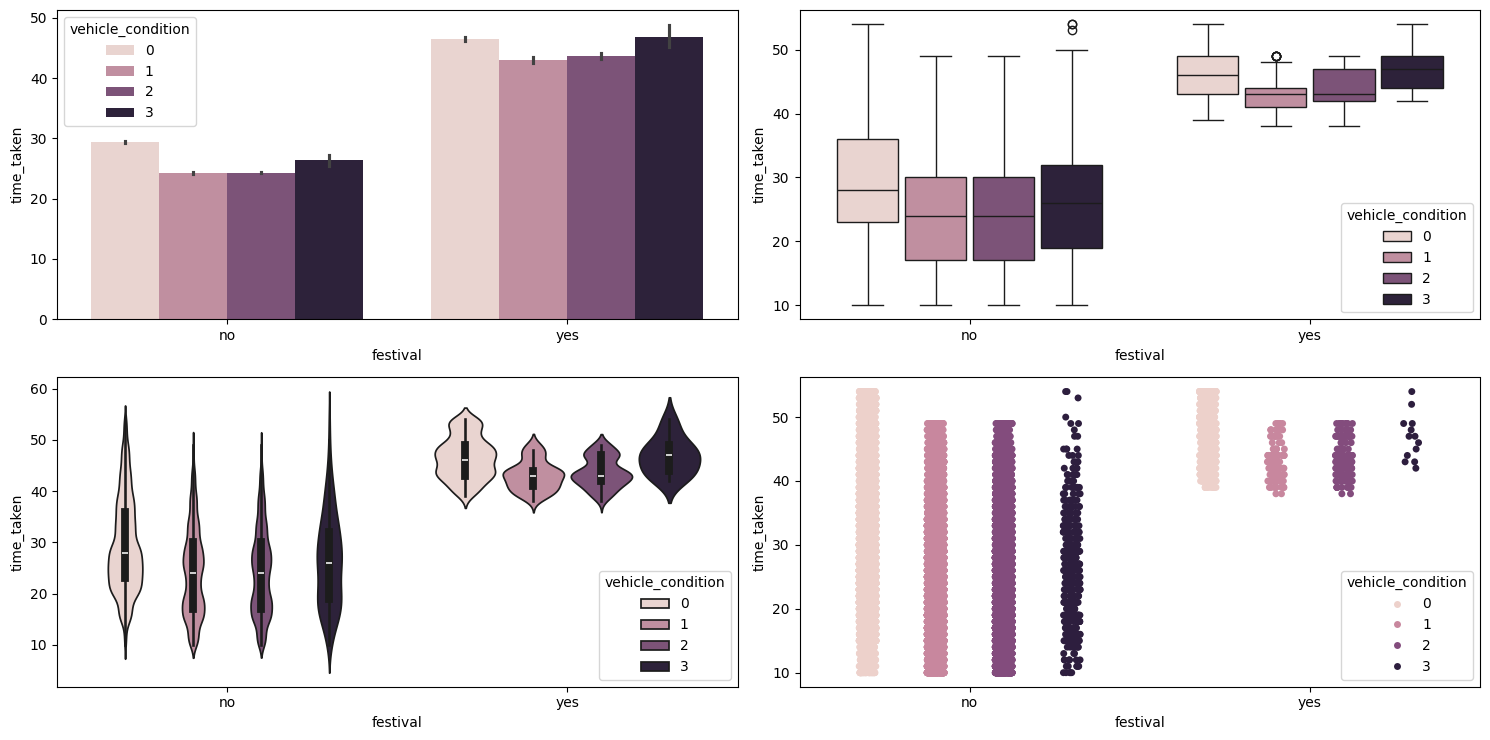

In [72]:
multivariate_analysis(df_final, "time_taken", "festival", "vehicle_condition")

# Multiple deliveries

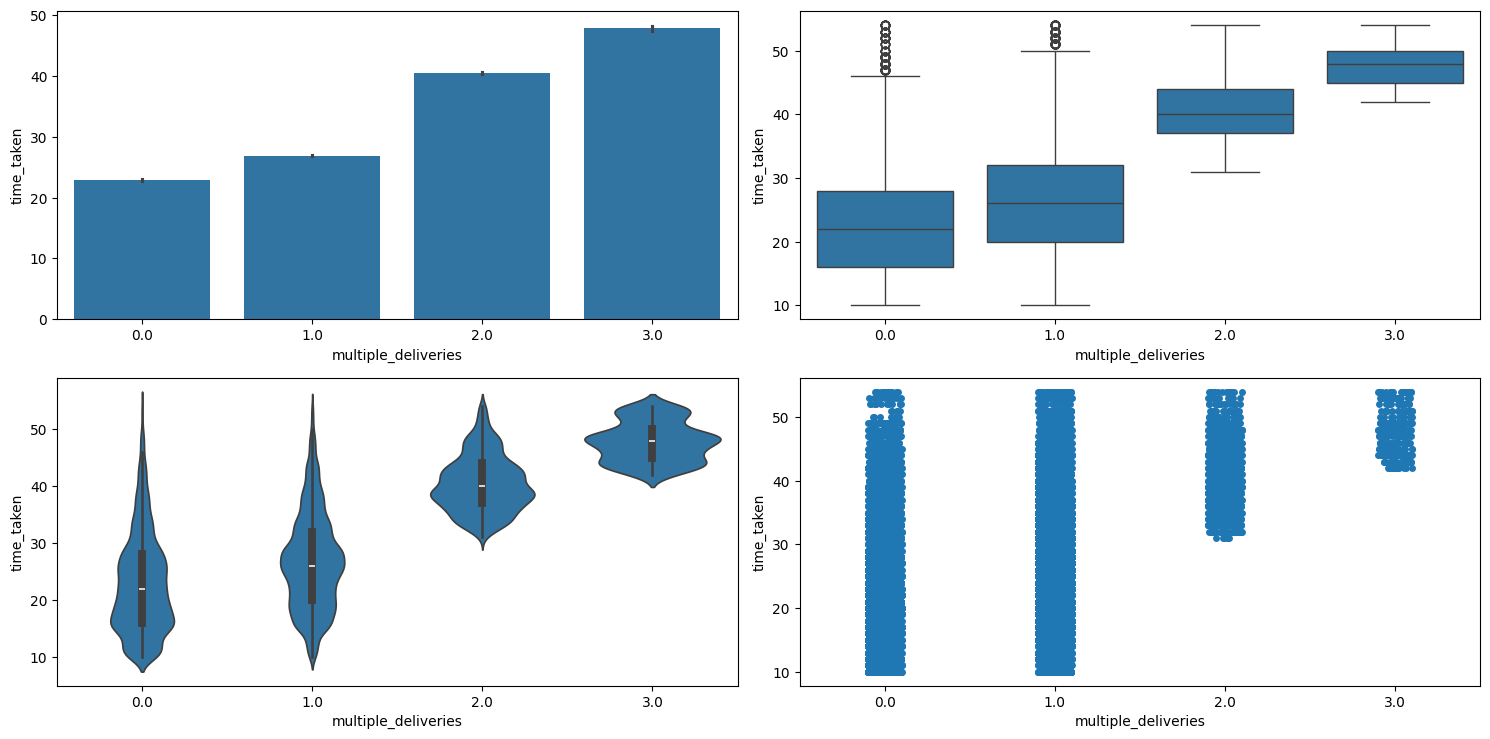

In [73]:
# does multiple delivereis affect delivery times

numerical_categorical_analysis(df_final, "multiple_deliveries", "time_taken")

In [74]:
# hypothesis test

anova_test(df_final, "time_taken", "multiple_deliveries")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and multiple_deliveries.


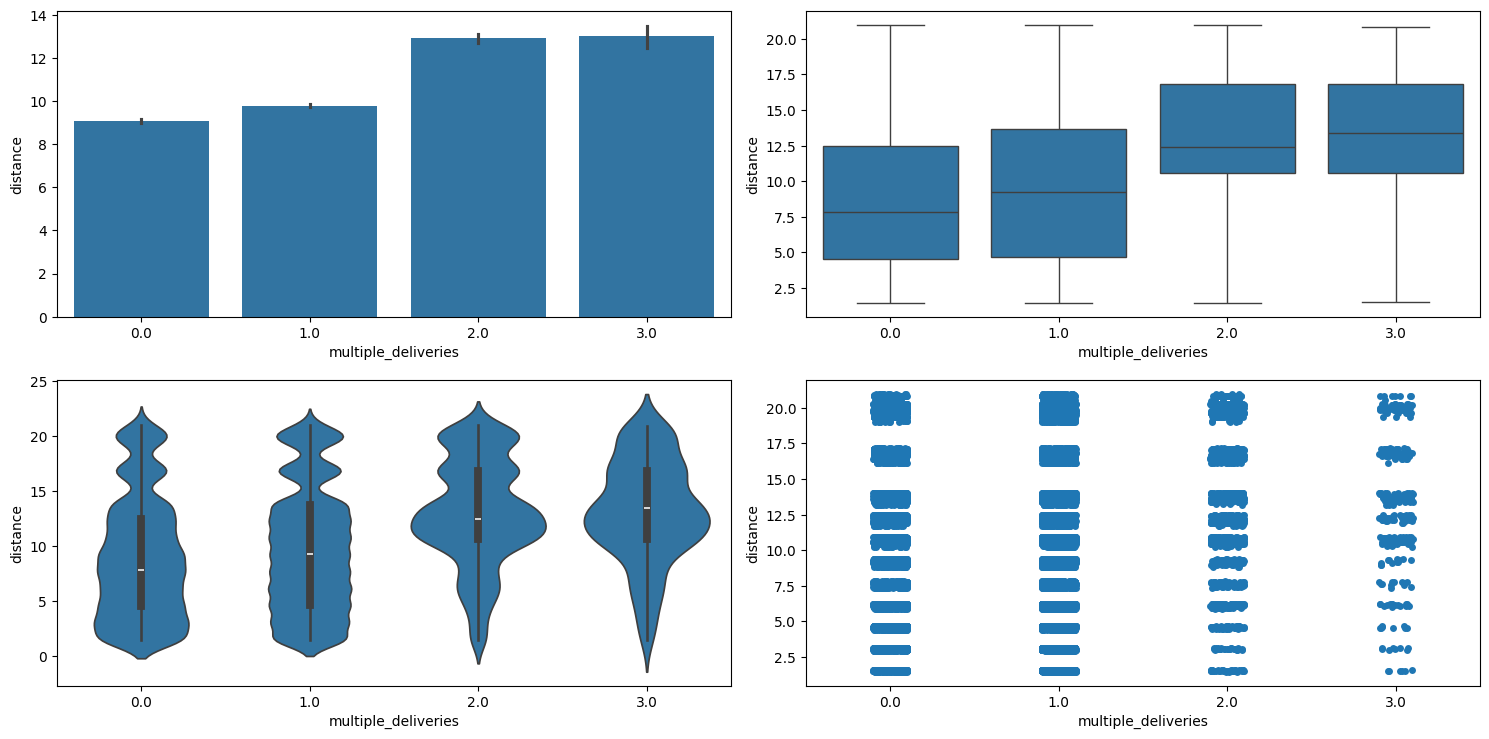

In [75]:
# do multiple deliveries are of longer distances

numerical_categorical_analysis(df_final, "multiple_deliveries", "distance")

## Weather

,Count,Percentage
weather,,
fog,7654,17.02%
stormy,7586,16.87%
cloudy,7536,16.76%
sandstorms,7495,16.66%
windy,7422,16.5%
sunny,7284,16.19%


**************************************************
The unique categories in weather column are ['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
**************************************************
The number of categories in weather column are 6


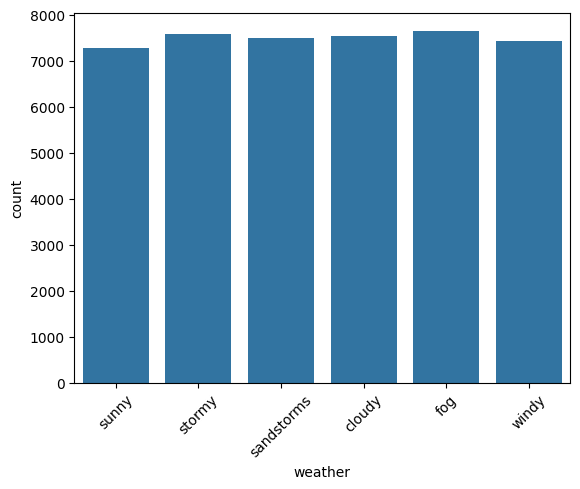

In [77]:
# categorical analysis on type of weather

categorical_analysis(df_final, "weather")

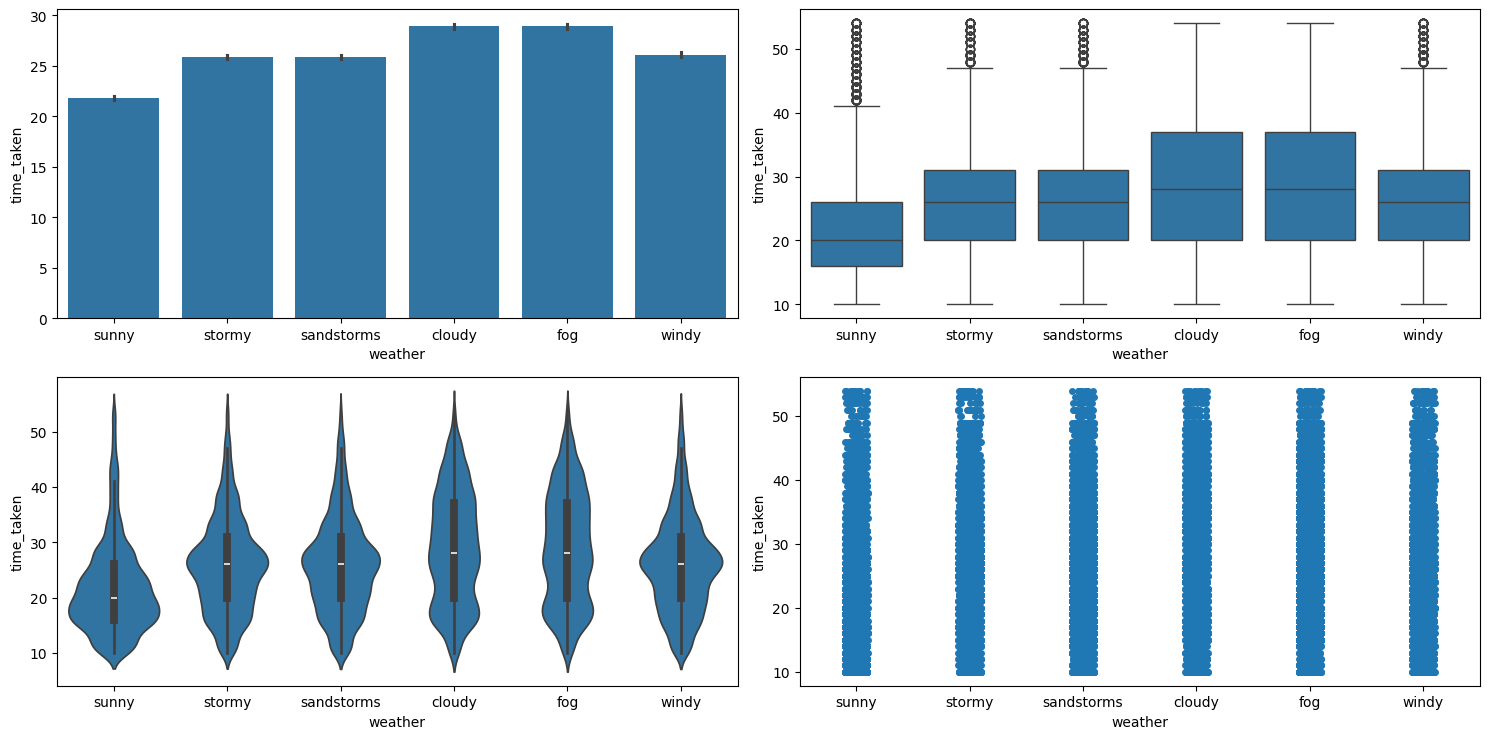

In [78]:
# does weather affect delivery times

numerical_categorical_analysis(df_final, "weather", "time_taken")

In [79]:
# hypothesis test

anova_test(df_final, "time_taken", "weather")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and weather.


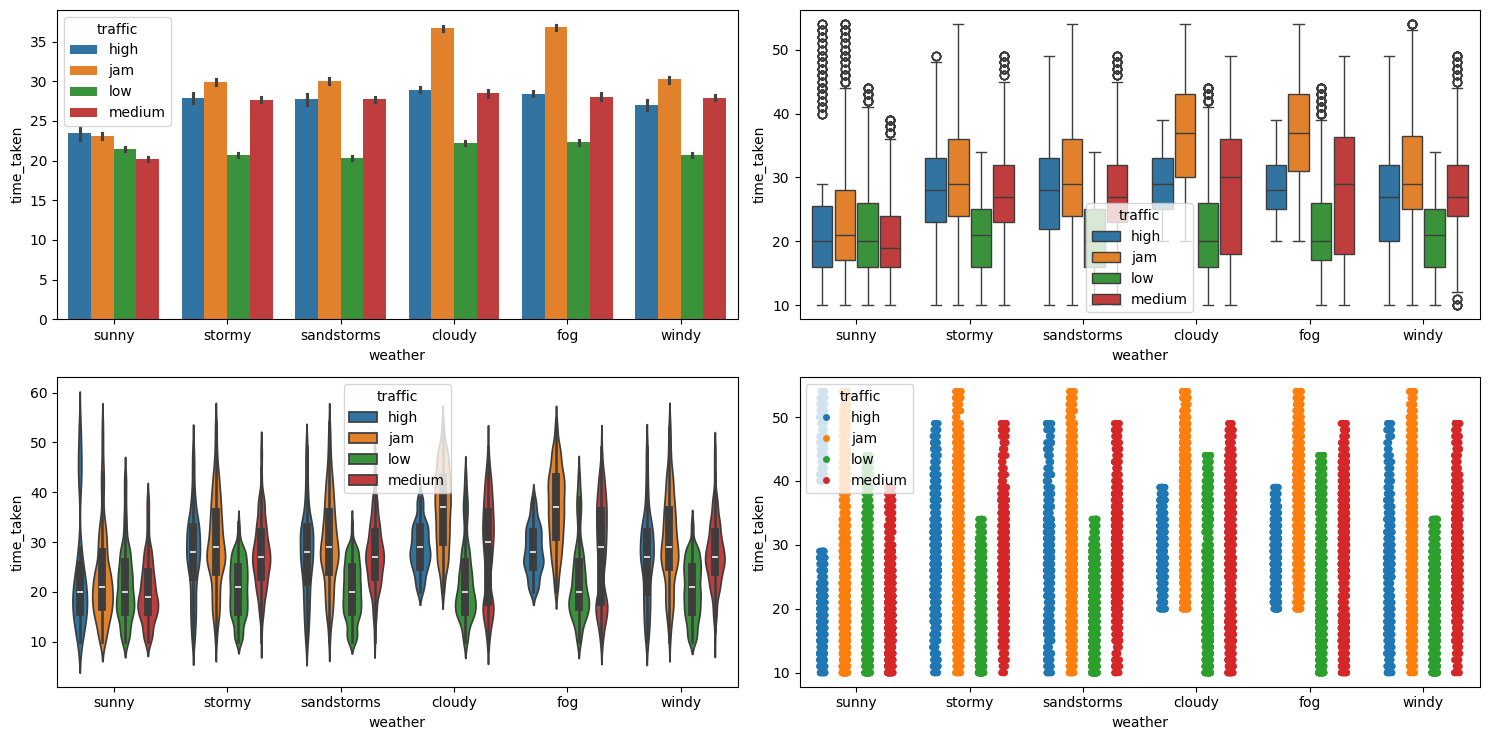

In [80]:
# delivery times based on weather and traffic

multivariate_analysis(df_final, "time_taken", "weather", "traffic")

Seems like traffic along with other features combined acts as great discriminatory feature

In [81]:
# pivot table

df_final.pivot_table(index="weather",columns="traffic",values="time_taken",aggfunc="mean")

traffic,high,jam,low,medium
weather,,,,
cloudy,28.940860,36.689655,22.208445,28.483134
fog,28.426546,36.806916,22.303427,28.044816
sandstorms,27.711840,30.018758,20.297049,27.738522
stormy,27.845839,29.850194,20.681734,27.680502
sunny,23.448980,23.082132,21.449293,20.195518
windy,26.972789,30.219056,20.665862,27.888769


# Vehicles

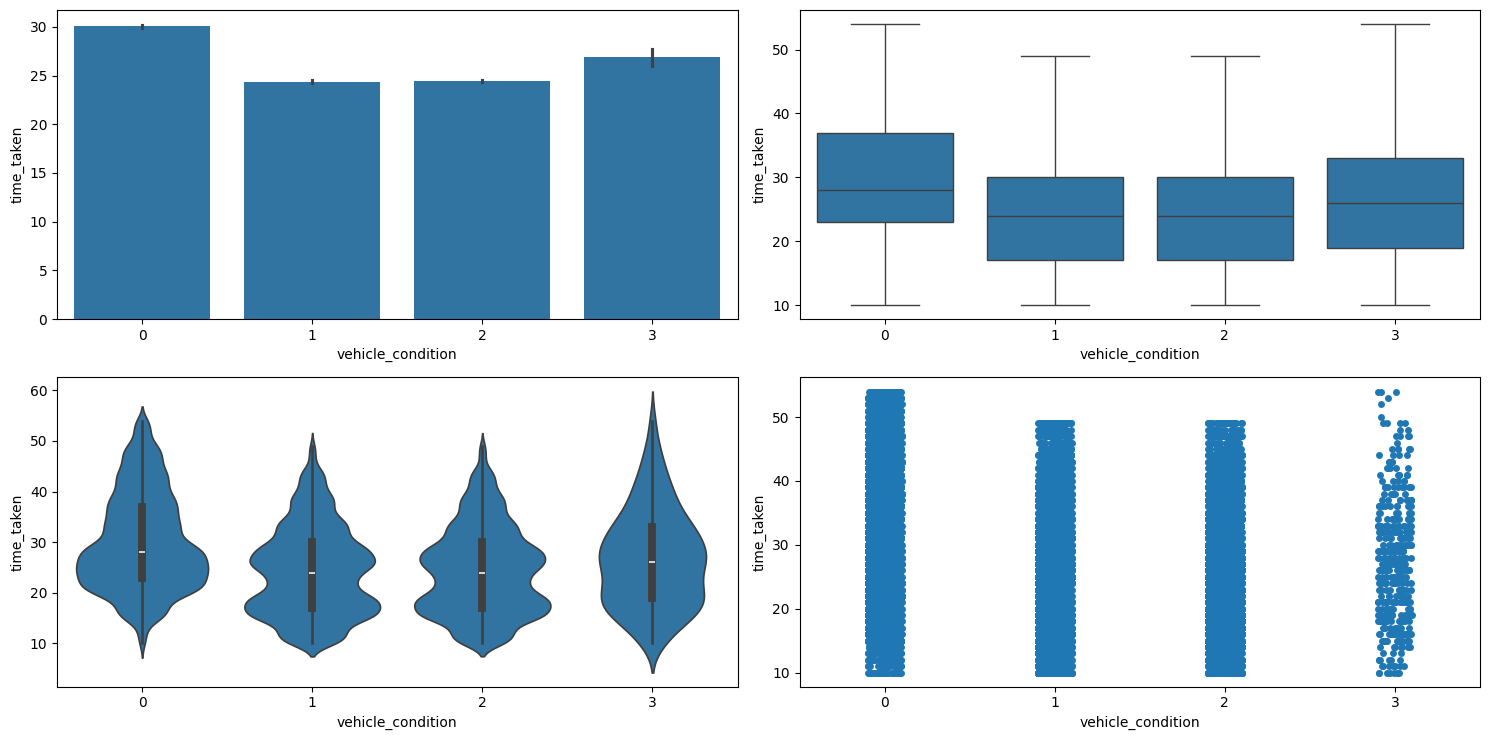

In [82]:
# does vehicle condition affect delivery times

numerical_categorical_analysis(df_final, "vehicle_condition", "time_taken")

In [83]:
# anova test

anova_test(df_final, "time_taken", "vehicle_condition")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and vehicle_condition.


,Count,Percentage
type_of_vehicle,,
motorcycle,26427,58.08%
scooter,15244,33.5%
electric_scooter,3778,8.3%
bicycle,53,0.12%


**************************************************
The unique categories in type_of_vehicle column are ['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
**************************************************
The number of categories in type_of_vehicle column are 4


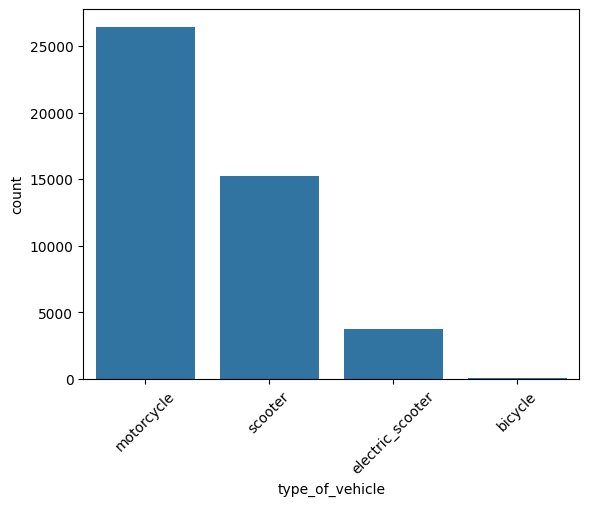

In [84]:
# analysis on vehicle type

categorical_analysis(df_final, "type_of_vehicle")

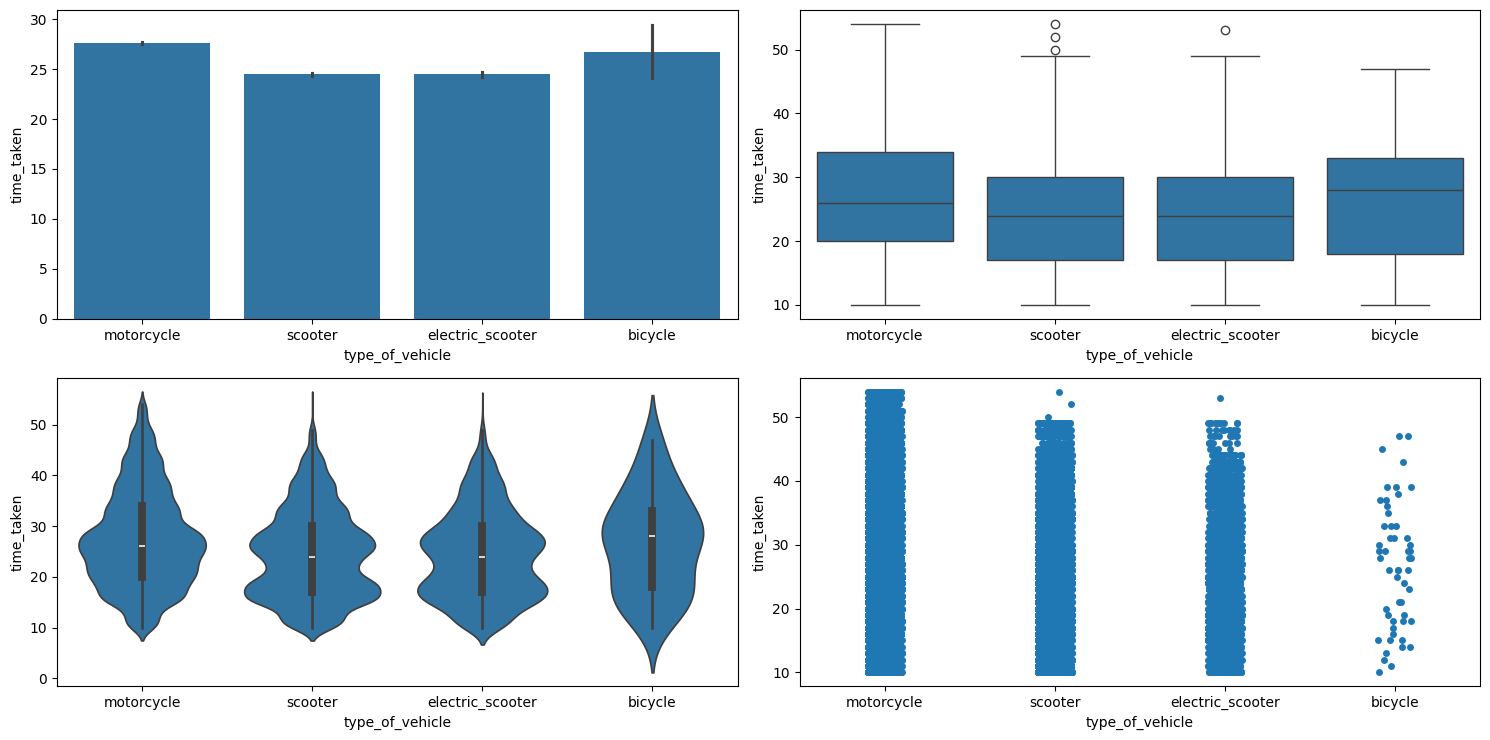

In [85]:
# does the type of vehicle affects delivery time

numerical_categorical_analysis(df_final, "type_of_vehicle", "time_taken")

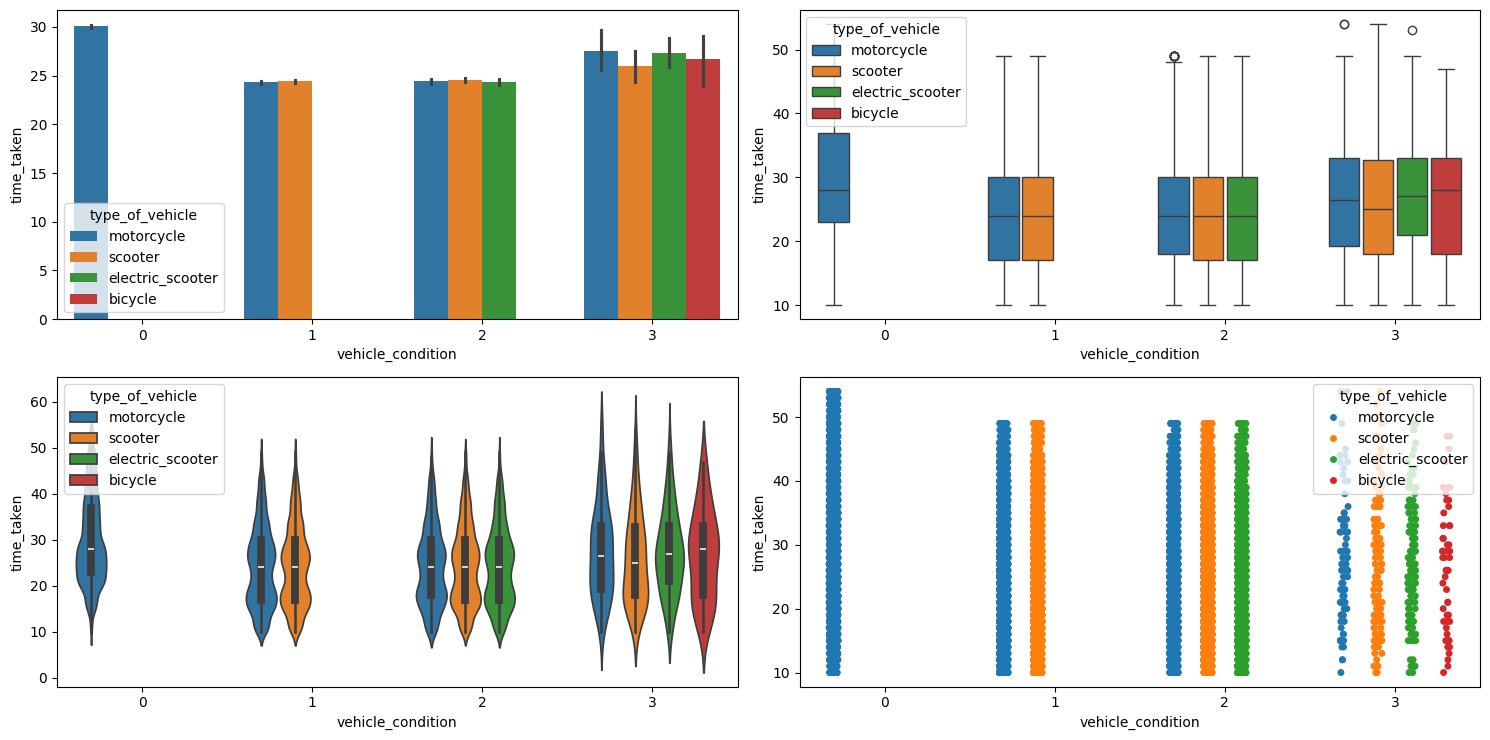

In [86]:
# vehicle condition and type

multivariate_analysis(df_final, "time_taken", "vehicle_condition", "type_of_vehicle")

In [87]:
# is their a relation between vehicle type and conditions

chi_2_test(df_final, "type_of_vehicle", "vehicle_condition")

0.0
Reject the null hypothesis. There is a significant association between type_of_vehicle and vehicle_condition.


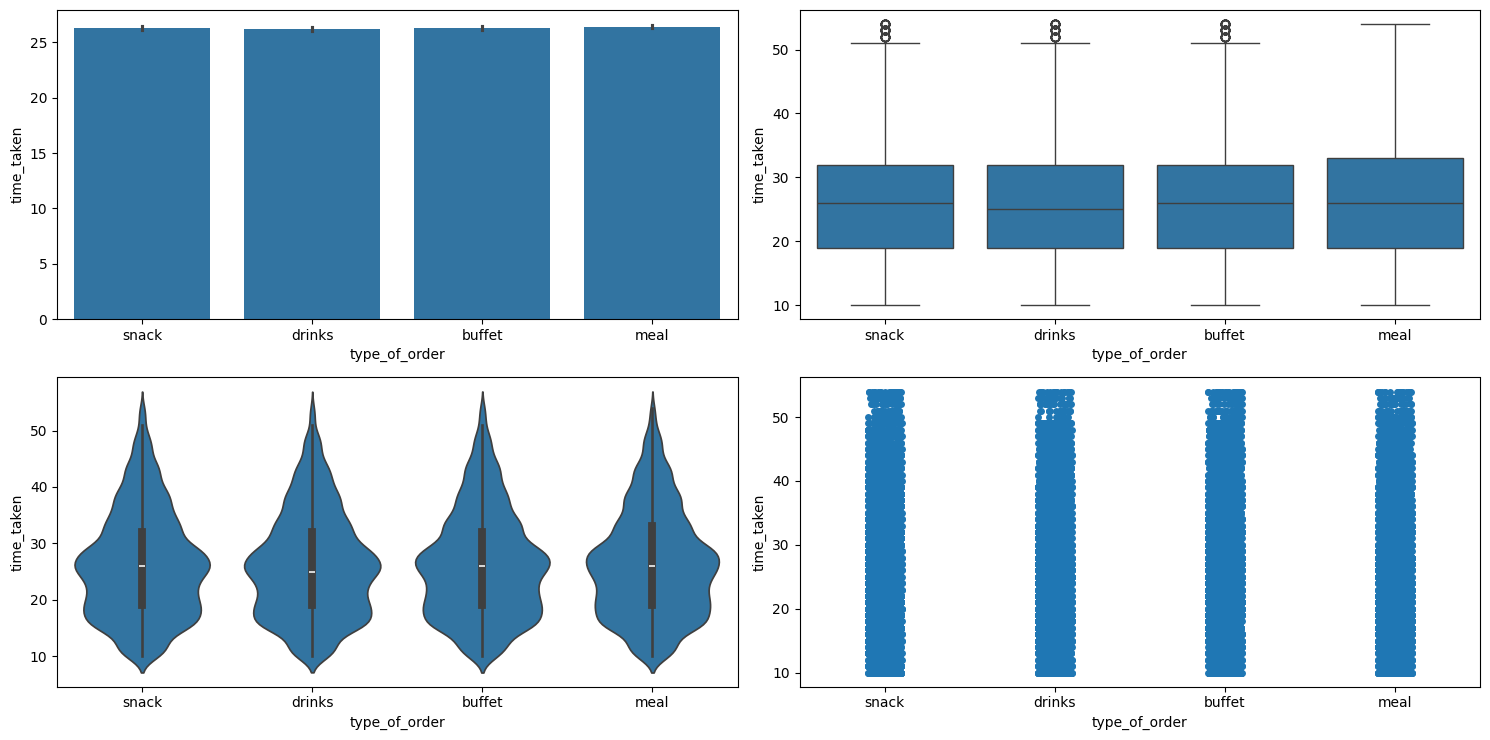

In [88]:
# does order type have have effect on delivery times

numerical_categorical_analysis(df_final, "type_of_order", "time_taken")

In [89]:
# hypothesis test

anova_test(df_final, "time_taken", "type_of_order")

0.304330987731464
Fail to reject the null hypothesis. There is no significant relationship between time_taken and type_of_order.


In [90]:
# contingency table

pd.crosstab(df_final["type_of_order"],df_final["is_weekend"])

is_weekend,0,1
type_of_order,,
buffet,8238,3023
drinks,8130,3164
meal,8290,3145
snack,8337,3175


In [91]:
# does type of order have an effect over pickup time

chi_2_test(df_final,"pickup_time_minutes","type_of_order")

0.49118080317709845
Fail to reject the null hypothesis. There is no significant association between pickup_time_minutes and type_of_order.


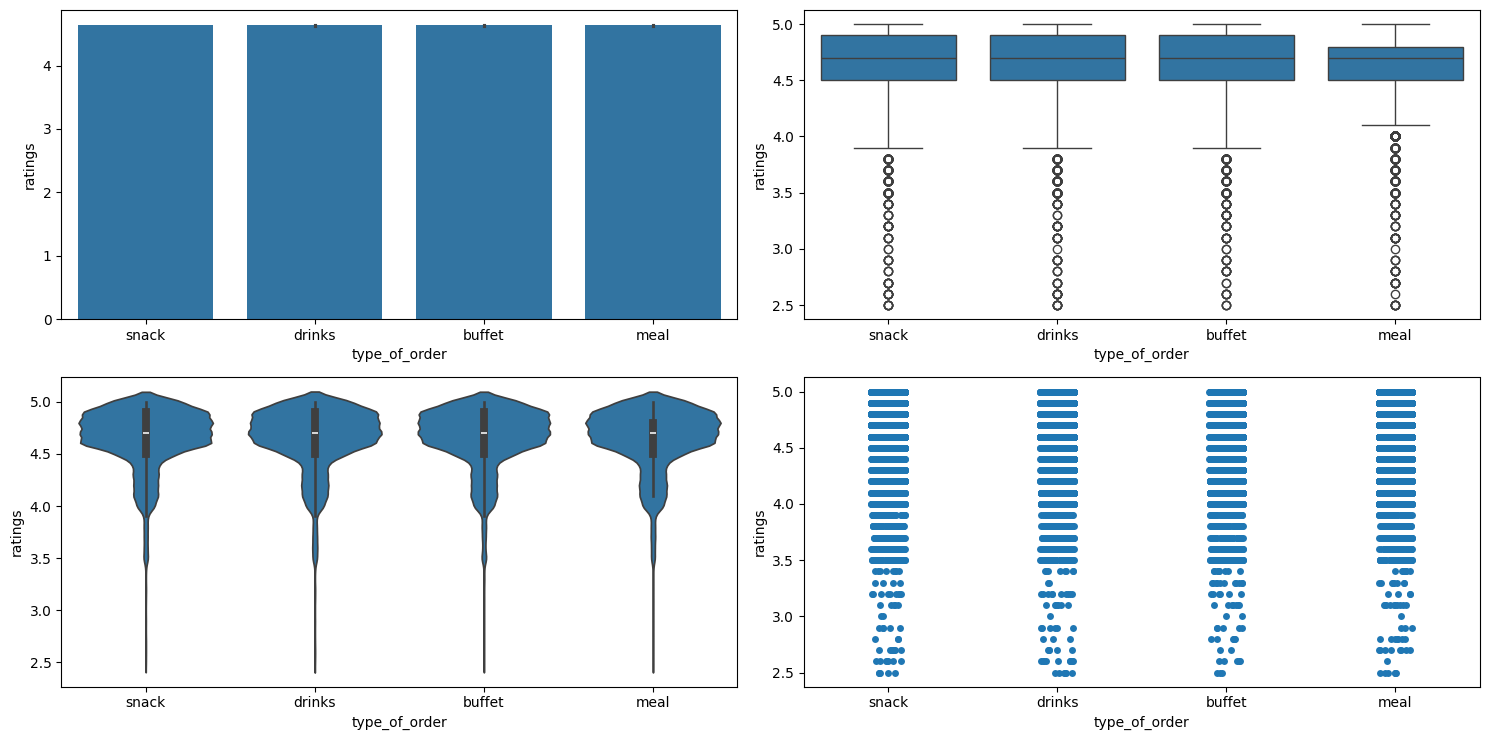

In [92]:
# does order type has an effect on ratings

numerical_categorical_analysis(df_final, "type_of_order", "ratings")

In [93]:
# is their a relationship between weekends and type of order

chi_2_test(df_final, "is_weekend", "type_of_order")

0.2658161540207276
Fail to reject the null hypothesis. There is no significant association between is_weekend and type_of_order.


In [94]:
# is their a relationship between festivals and type of order

chi_2_test(df_final, "festival", "type_of_order")

0.6149018072722126
Fail to reject the null hypothesis. There is no significant association between festival and type_of_order.


# City Name

,Count,Percentage
city_name,,
JAP,3439,7.56%
RANCHI,3222,7.08%
BANG,3184,7.0%
SUR,3182,6.99%
HYD,3177,6.98%
MUM,3168,6.96%
MYS,3164,6.95%
COIMB,3162,6.95%
VAD,3159,6.94%


**************************************************
The unique categories in city_name column are ['INDO', 'BANG', 'COIMB', 'CHEN', 'HYD', 'RANCHI', 'MYS', 'DEH', 'KOC', 'PUNE', 'LUDH', 'KNP', 'MUM', 'KOL', 'JAP', 'SUR', 'GOA', 'AURG', 'AGR', 'VAD', 'ALH', 'BHP']
**************************************************
The number of categories in city_name column are 22


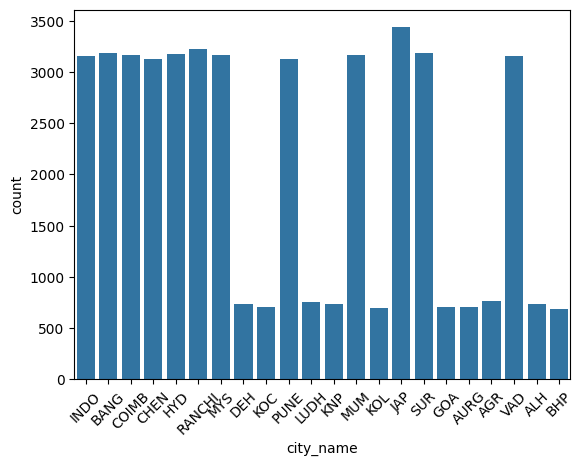

In [95]:
# categorical analysis on city name

categorical_analysis(df_final, "city_name")

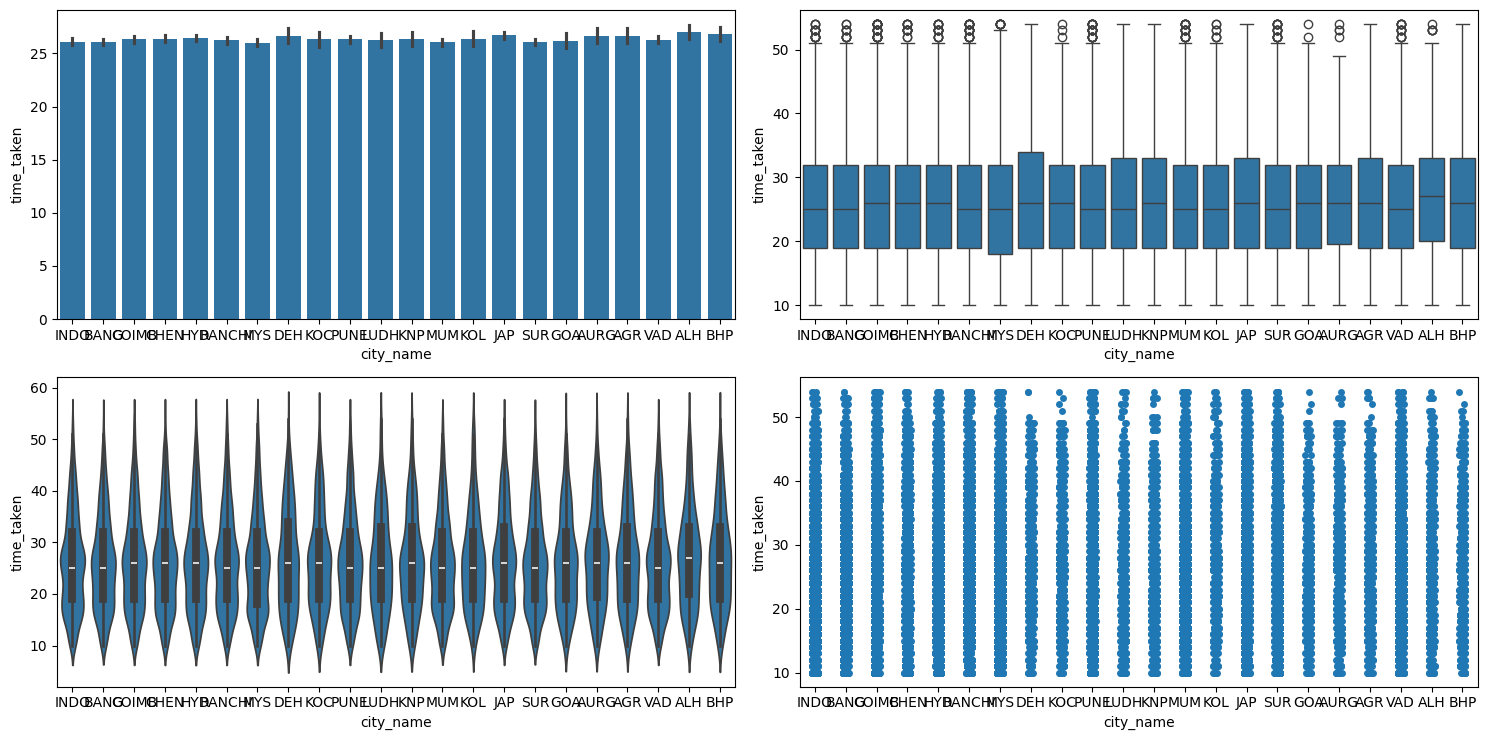

In [96]:
# does a city affects delivery times

numerical_categorical_analysis(df_final, "city_name", "time_taken")

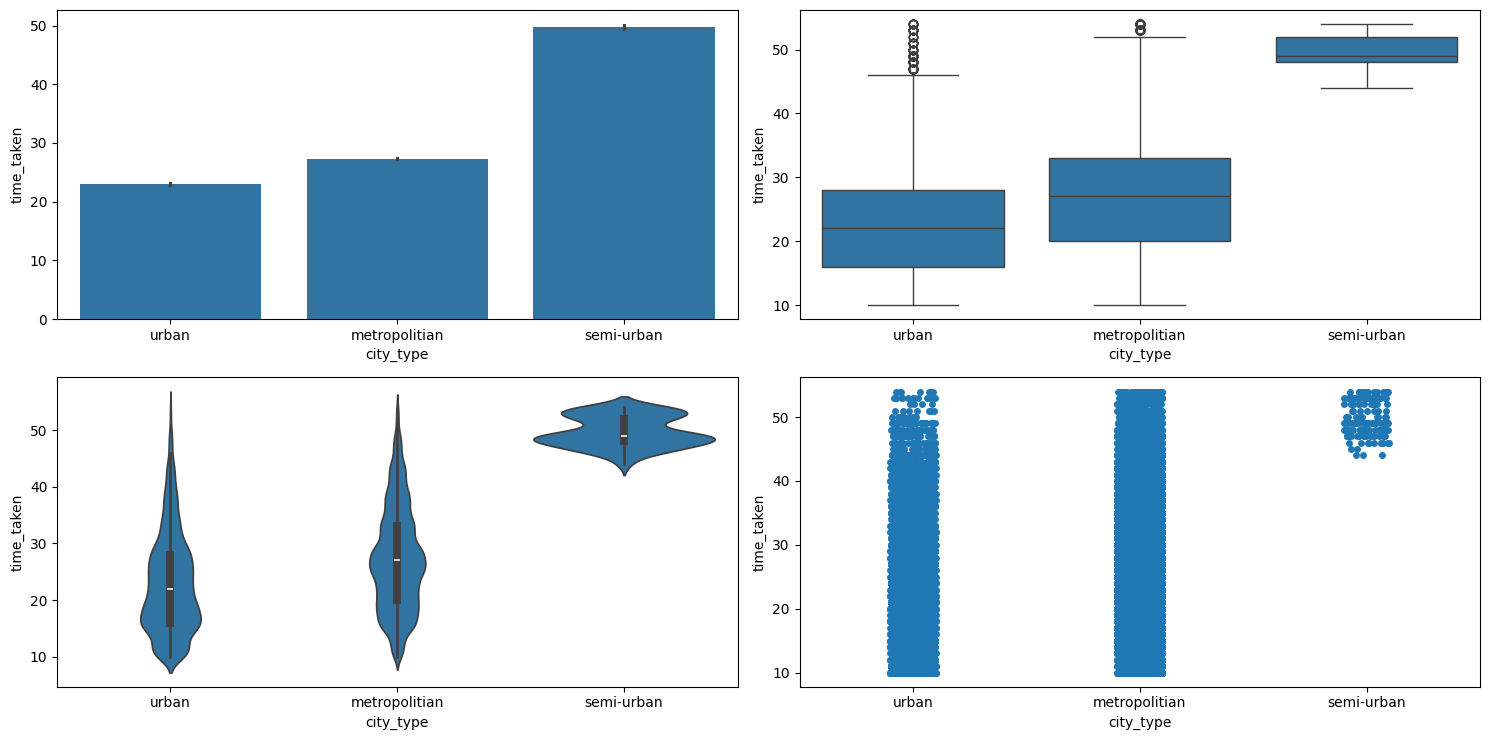

In [97]:
# does city types affect delivery times

numerical_categorical_analysis(df_final, "city_type", "time_taken")

In [98]:
# hypothesis test

anova_test(df_final, "time_taken", "city_type")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and city_type.


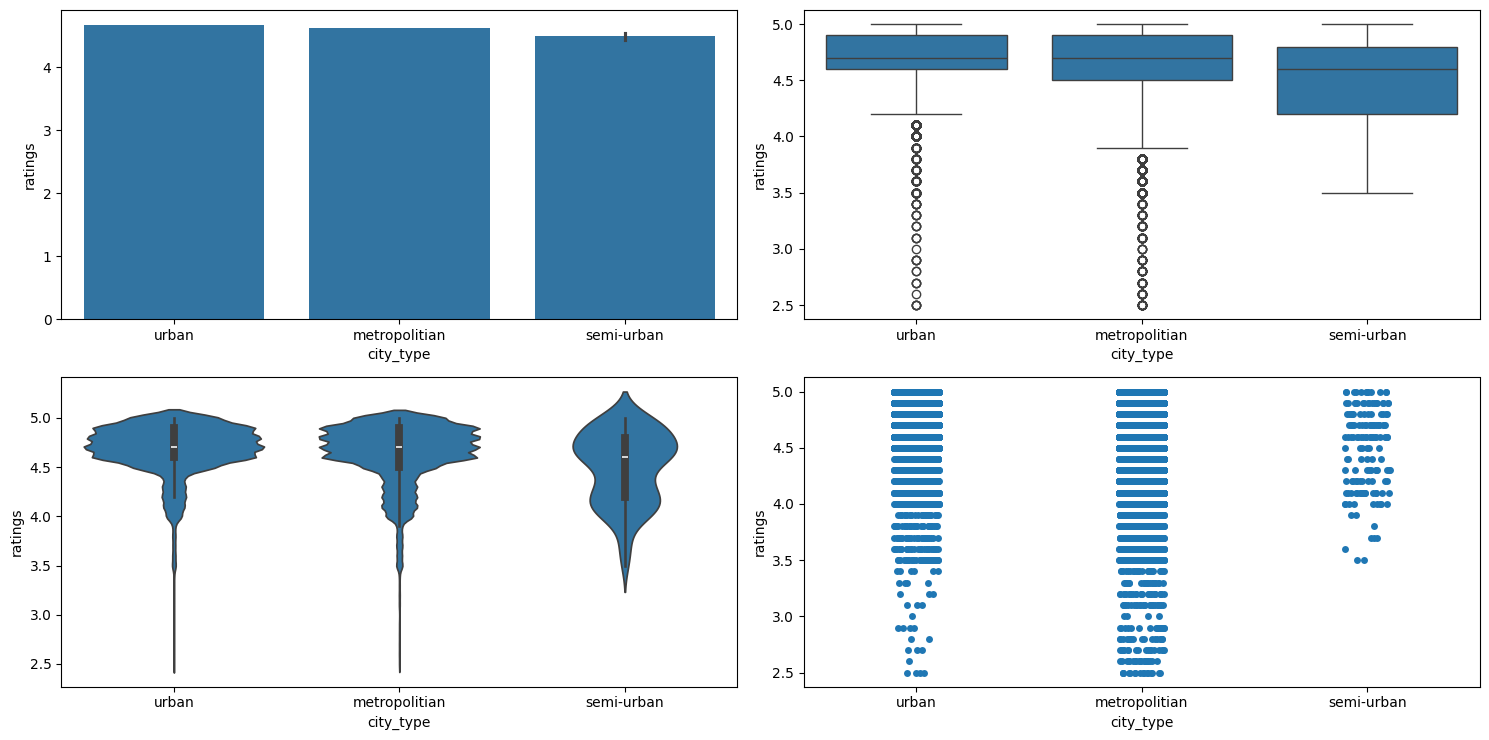

In [99]:
# does city type affects rider ratings

numerical_categorical_analysis(df_final, "city_type", "ratings")

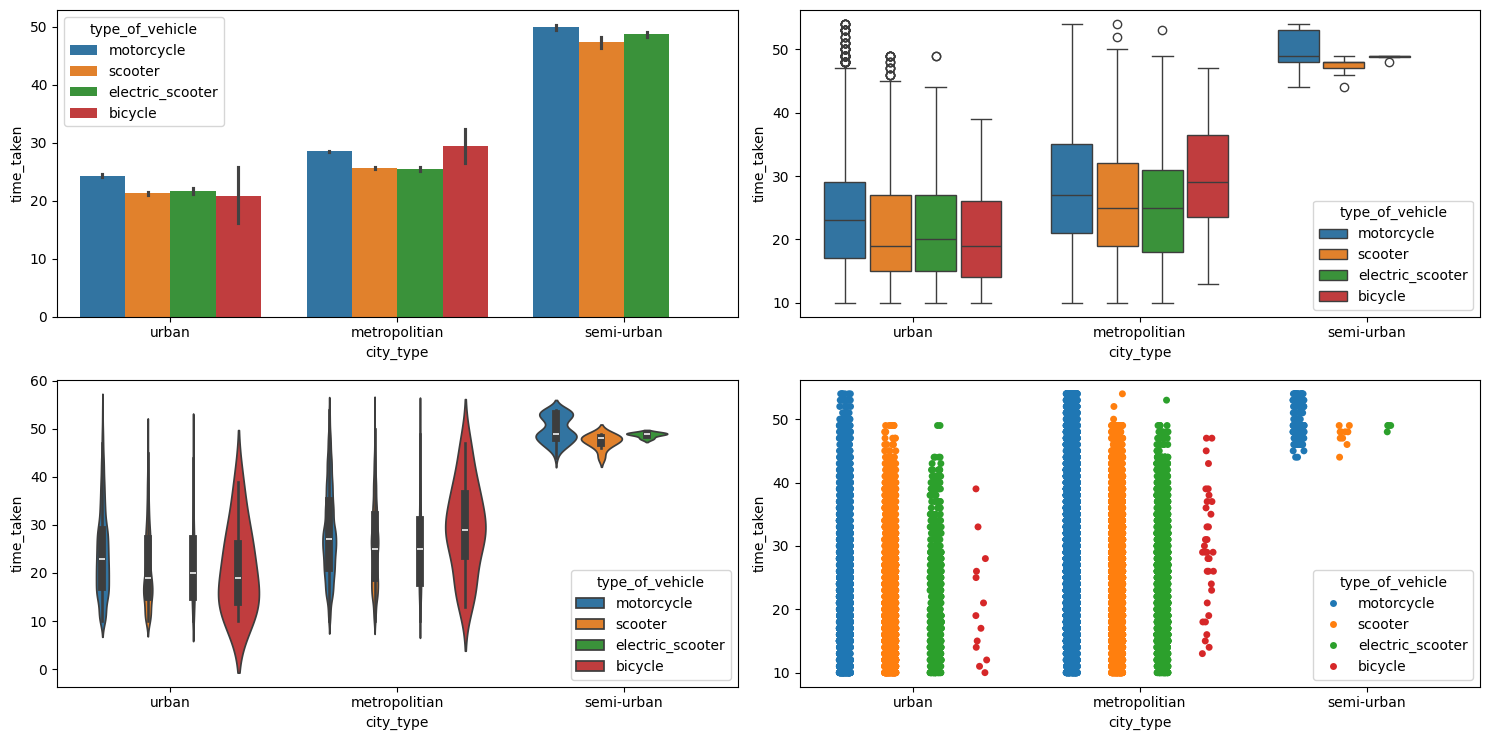

In [100]:
# city type, type of vehicle and delivery time analysis

multivariate_analysis(df_final, "time_taken", "city_type", "type_of_vehicle")

# Distance

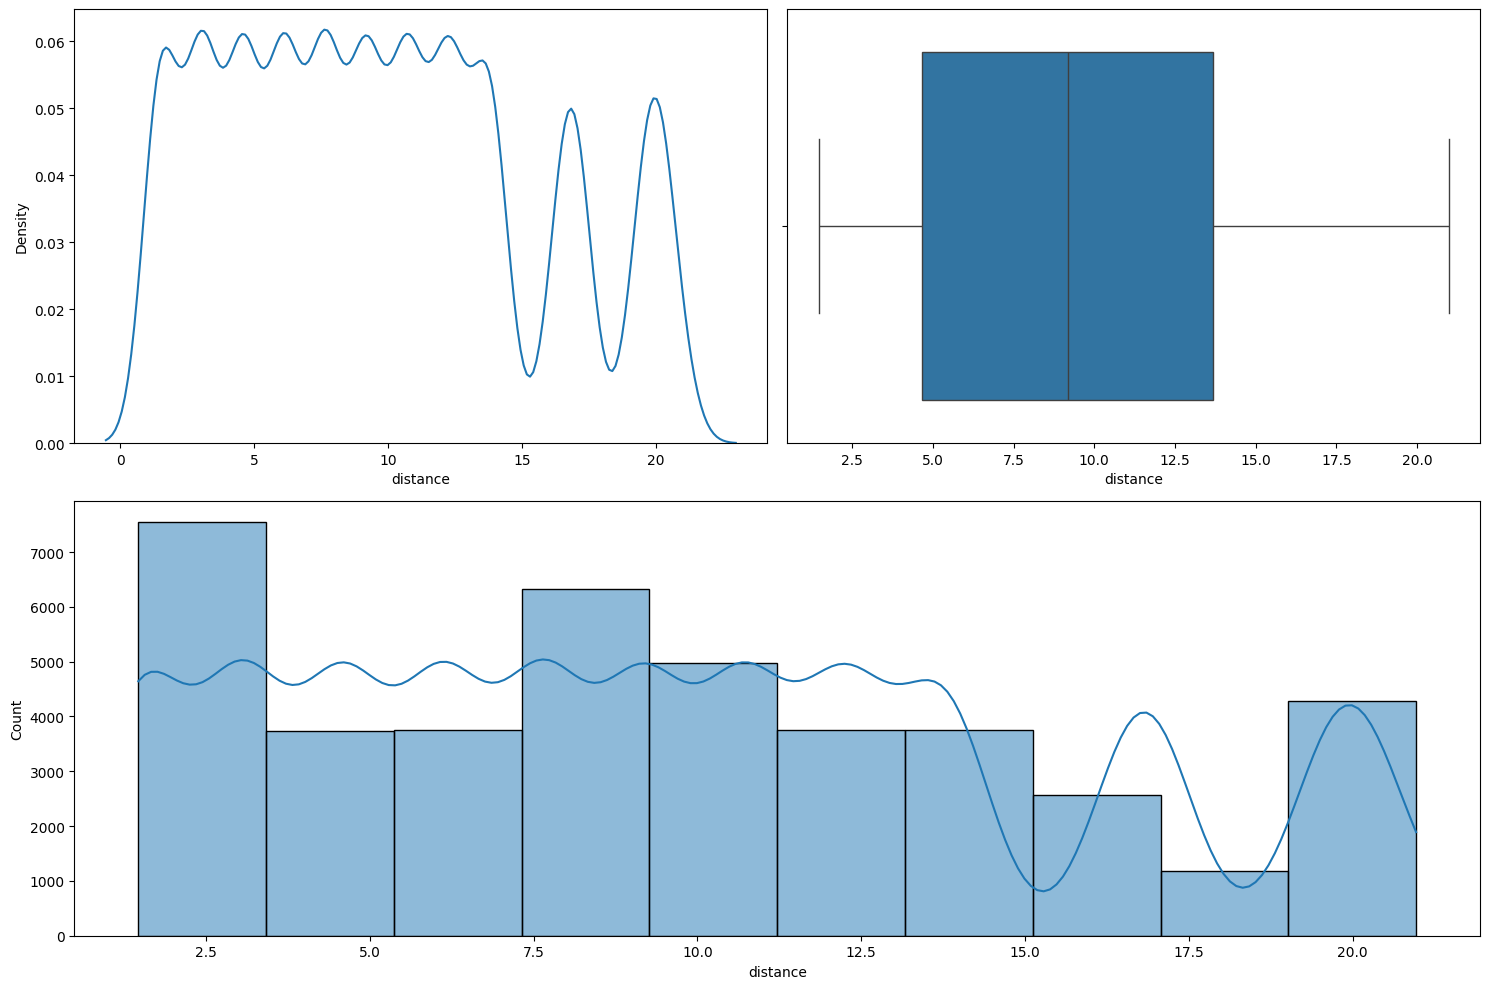

In [102]:
# numerical analysis of distance

numerical_analysis(df_final, "distance",bins=10)

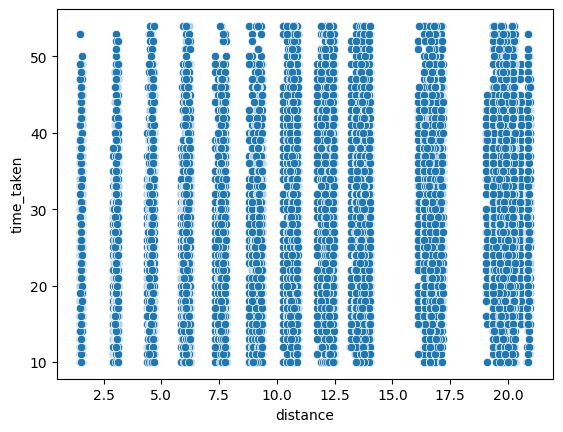

In [103]:
# relationship between distance and delivery times

sns.scatterplot(df_final,x="distance",y="time_taken")
plt.show()

In [104]:
# corr

df_final[["distance","time_taken"]].corr()

,distance,time_taken
distance,1.000000,0.320705
time_taken,0.320705,1.000000


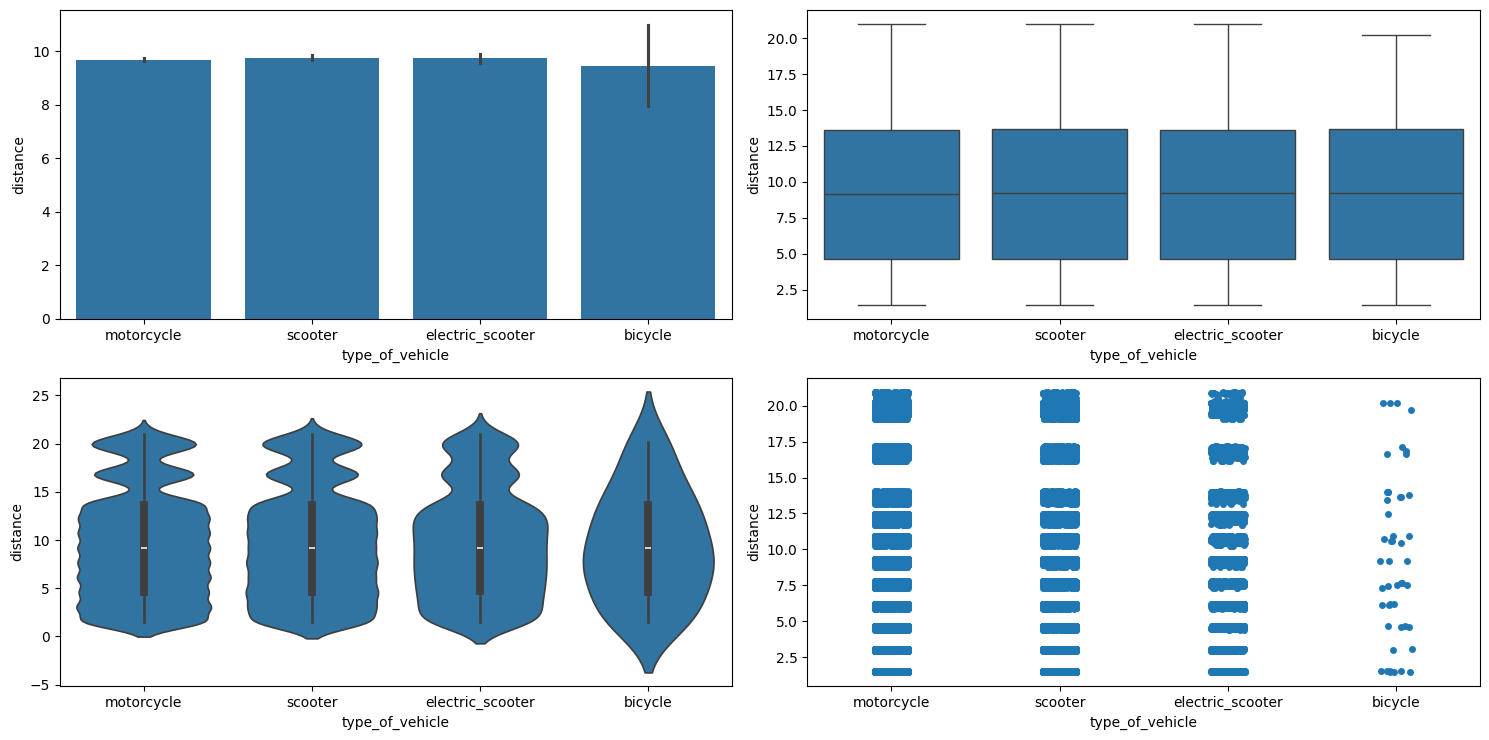

In [105]:
# vehicle type and distance analysis

numerical_categorical_analysis(df_final, "type_of_vehicle", "distance")

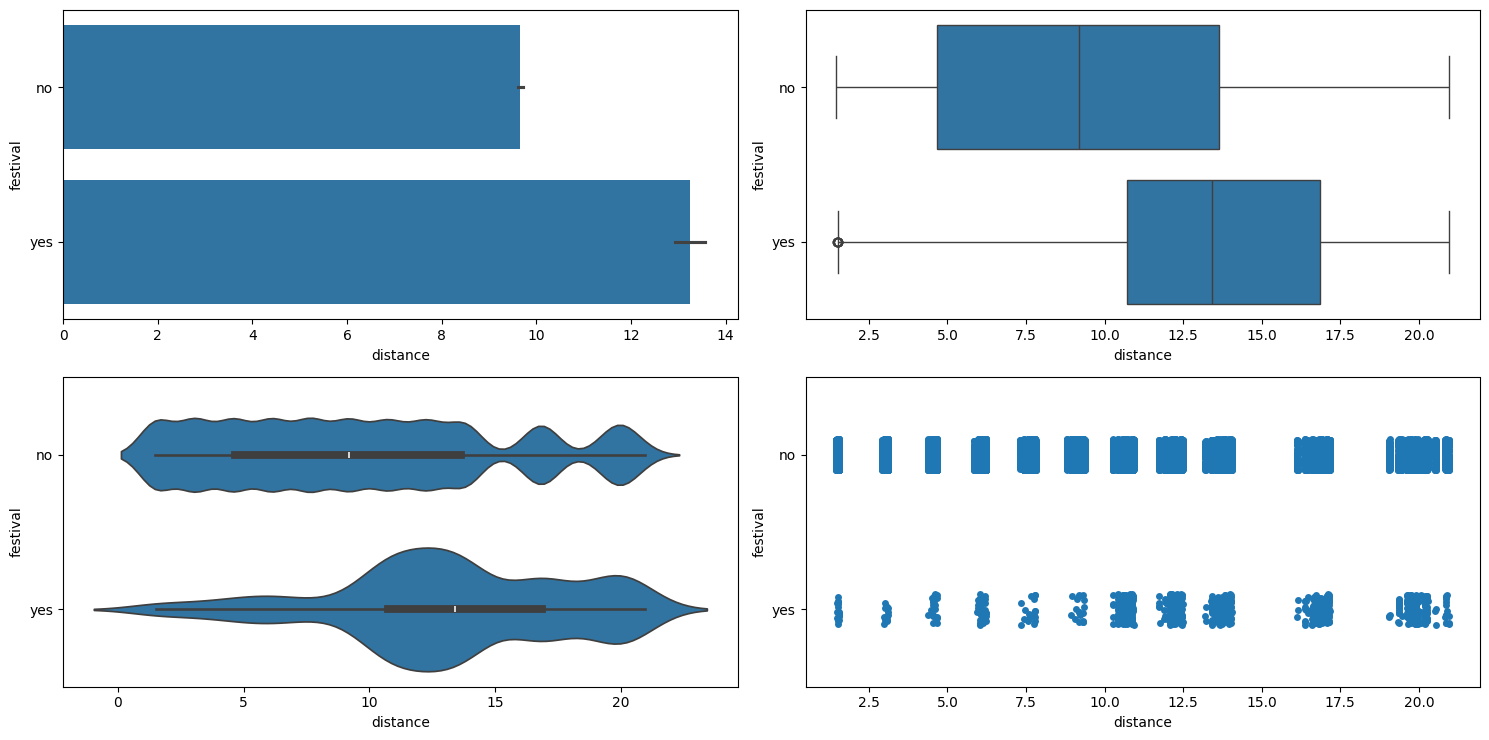

In [106]:
# do riders cover more distances during festivals

numerical_categorical_analysis(df_final, "distance", "festival")

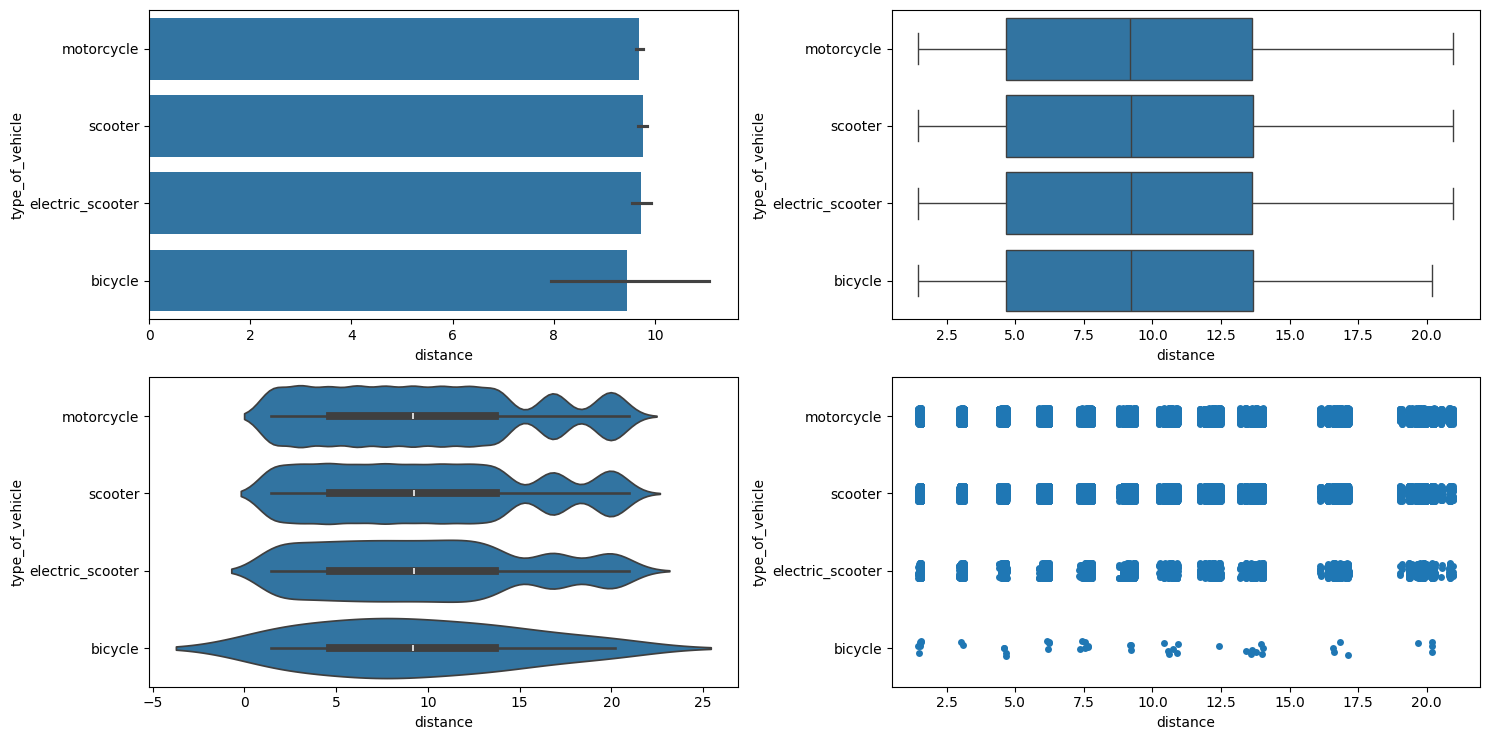

In [107]:
# distance and type of vehicle

numerical_categorical_analysis(df_final, "distance", "type_of_vehicle")